In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

## phyloseq cleanup

In [3]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [4]:
## removing diseased_margin from ps_col

#new dataframes for each species 
ps_nomargin <- subset_samples(ps, Health_status != "Diseased_Margin")

#how many samples did I remove?
ps_nomargin

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 450 samples ]
sample_data() Sample Data:       [ 450 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [5]:
#prune just before 

In [6]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps_nomargin) >= 10000, ps_nomargin)
ps_high
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 445 samples ]
sample_data() Sample Data:       [ 445 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 445 samples ]
sample_data() Sample Data:       [ 445 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

## hmm what is happening here? I have allegedly already pruned the taxa that don't show up
- when I do not prune_taxa at first I still end up with the same 46,457

In [7]:
#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46535 taxa and 445 samples ]
sample_data() Sample Data:       [ 445 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46535 taxa by 6 taxonomic ranks ]

### to do
- investigate which taxa are missing

In [8]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))

## convert the sample_data() within a phyloseq object to a vegan compatible data object

In [9]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_norm)$Month_year <- factor(sample_data(ps_norm)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


## extract sample_Data with vegan to group by repeated colonies

In [10]:
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

sample_nomit <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

### new repeated colonies only dataframe

In [11]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

[1] 445

[1] 428

In [12]:
#how many colonies are represented?
length(unique(colonies$colony))

[1] 64

In [13]:
head(colonies)

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,SampleID
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>
Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID,052022_BEL_CBC_T1_2_SSID
Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST,092023_BEL_CBC_T1_175_PAST
Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR,022024_BEL_CBC_T3_851_PSTR
Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV,082024_BEL_CBC_T4_1609_OFAV
Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID,122023_BEL_CBC_T3_526_SSID
Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV,112023_BEL_CBC_T4_399_MCAV


In [14]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [15]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_norm))

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] 445

In [16]:
head(colonies)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID,052022_BEL_CBC_T1_2_SSID
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST,092023_BEL_CBC_T1_175_PAST
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR,022024_BEL_CBC_T3_851_PSTR
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV,082024_BEL_CBC_T4_1609_OFAV
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID,122023_BEL_CBC_T3_526_SSID
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV,112023_BEL_CBC_T4_399_MCAV


## reorder colonies by if they were ever diseased/ only experienced bleaching
- before labelling colonies that were only ever paled
``` 
# group colonies by if they ever had disease or bleaching
colony_history <- colonies %>%
  group_by(colony) %>% 
# Summarize to see if they ever had these statuses
  summarize(
    ever_diseased = any(Condition == "Diseased"),
    ever_bleached = any(Health_status == "Bleached_Tissue")
  ) 
```
- then use the code to label diseased vs bleached
```
# 3. Now create the labels and arrange them
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), colony) %>%   # Arrange: Diseased first, then Bleached, then Healthy/Others
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    TRUE                  ~ as.character(colony)
  ))

# 4. Extract the ordered vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label
```

## showcase the 14 colonies that only ever experienced paling
- grepl("CLB", Condition): This searches for the text "CLB" anywhere in that row, catching both "CLB" and "CLP,CLB".

- !ever_bleached: By adding this constraint to only_paled, you ensure that if a colony eventually bleached later in the 12 time points, it gets excluded from the "paled only" group and correctly categorized as "ever bleached".

- no longer using Health_status for bleaching or disease because it is vague

In [17]:
## how many colonies only ever experienced paling?
paling_only_count <- colonies %>%
  group_by(colony) %>%
  summarize(
    ever_paled = any(Condition == "CLP"),
    ever_fully_bleached = any(Condition %in% c("CLP,CLB", "CLB"))
  ) %>%
  # Filter for colonies that paled, but NEVER fully bleached
  filter(ever_paled == TRUE & ever_fully_bleached == FALSE) %>% 
  nrow()

print(paling_only_count)

[1] 14


In [18]:
#group by colony
colony_history <- colonies %>%
  group_by(colony) %>%
  summarize(
    # ever_diseased means that the colony was diagnosed with SCTLD
    ever_diseased = any(Condition == "Diseased"),
    
    # ever_bleached strictly means it hit full bleaching (CLB or CLP,CLB)
    ever_bleached = any(grepl("CLB", Condition)),
    
    # only_paled means it had CLP, but NEVER progressed to having CLB
    only_paled    = any(grepl("CLP", Condition)) & !ever_bleached
  )

# The rest of your labeling and arranging code works exactly the same:
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), desc(only_paled), colony) %>%
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    only_paled    == TRUE ~ paste(colony, "(Paled Only)"),
    TRUE                  ~ as.character(colony)
  ))

In [19]:
# 3. Extract your vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label

## create a new phyloseq object with colonies dataframe

In [20]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_norm))  # Should be 421

[1] 428

[1] 428

In [21]:
head(sample_names(ps_norm))
head(keep_samples)

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

In [22]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)
     

In [23]:
## check up on ps_col
class(ps_col)
nrow(sample_data(ps_col))

all(rownames(colonies) %in% sample_names(ps_col))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 428

[1] TRUE

In [24]:
ps_col 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46535 taxa and 428 samples ]
sample_data() Sample Data:       [ 428 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46535 taxa by 6 taxonomic ranks ]

In [25]:
#checking on ps_col
nrow(sample_data(ps_col))
head(sample_data(ps_col))

[1] 428

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


## make sure ps_col is in chronological order and will be ordered by health status

In [26]:
unique(colonies$Month_year)

[1] May 2022 Sep 2023 Feb 2024 Aug 2024 Dec 2023 Nov 2023 Apr 2024 Jun 2019
 [9] Dec 2022 Oct 2019 Jun 2024 Jan 2024 <NA>    
12 Levels: Jun 2019 Oct 2019 May 2022 Dec 2022 Sep 2023 Nov 2023 ... Aug 2024

In [27]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

In [28]:
# adding diseased vs bleached labels to facets

#create new col colony_labeled 

current_colonies <- sample_data(ps_col)$colony

# Create a column in sample_data(ps_col) where the disease, CLB, CLp VALUES are the labels, but the LEVELS dictate the order
sample_data(ps_col)$colony_labeled <- factor(
  colony_order_df$colony_label[match(current_colonies, colony_order_df$colony)],
  levels = ordered_labels
)

# what family taxa are represented in different coral species?

### color idea
- assign colors by taxa and use microshades package to differentiate family taxa

In [29]:
  # how many unique family taxa are there total?
length(unique(tax_table(ps_col)[, "Phylum"]))
length(unique(tax_table(ps_col)[, "Order"]))
length(unique(tax_table(ps_col)[, "Family"]))

[1] 46

[1] 210

[1] 469

## try isolating ps_fam first and then making the phycolors based on the psfam dataframe

In [30]:
#isolating top 100 family taxa

# 1. Isolate Family level
ps_fam <- tax_glom(ps_col, taxrank = "Family")

In [31]:
ps_fam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 479 taxa and 428 samples ]
sample_data() Sample Data:       [ 428 samples by 11 sample variables ]
tax_table()   Taxonomy Table:    [ 479 taxa by 6 taxonomic ranks ]

In [32]:
#isolating top 100 family taxa
top300<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:300] 
ps_fam300 <- prune_taxa(top300, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam300)[, "Family"]))
length(unique(tax_table(ps_fam300)[, "Phylum"]))

[1] 296

[1] 36

## color ps_fam300 based on phylum

In [131]:
# --- 1. Get unique phyla cleanly as character strings ---
phylum <- as.character(unique(tax_table(ps_fam300)[, "Phylum"]))
head(phylum)

[1] "Pseudomonadota"  "Acidobacteriota" "Bacteroidota"    "Nitrospirota"   
[5] "Cyanobacteriota" "Dadabacteria"

In [161]:
## try a larger range of colors

hues <- seq(15, 375, length.out = 36 + 1)[1:36]

# 1. Sine wave for Luminance: peaks at Yellow (90) and drops at Blue (270)
# This prevents yellow from clipping to green/brown!
l_vals <- 55 + 25 * sin((hues - 15) * pi / 180)

# 2. Alternating Chroma: high/low pattern so colors alternate between pastel & vibrant
# This keeps colors physically displayable on your screen (inside the RGB gamut)
c_vals <- rep(c(85, 45, 65), length.out = 36)

# 3. Generate your safe, broad-range colors
phycolors_ramp <- hcl(h = hues, c = c_vals, l = l_vals)

# 4. Shuffle reproducibly
# i like seet 6, 8
set.seed(13)
phycolors <- sample(phycolors_ramp)

# 5. Assign names
names(phycolors) <- phylum

In [162]:
head(phycolors)

Pseudomonadota Acidobacteriota    Bacteroidota    Nitrospirota Cyanobacteriota 
      "#005A98"       "#D0895E"       "#A9D640"       "#46D773"       "#D4B359" 
   Dadabacteria 
      "#00C294"

## top 37/46 phylum plot

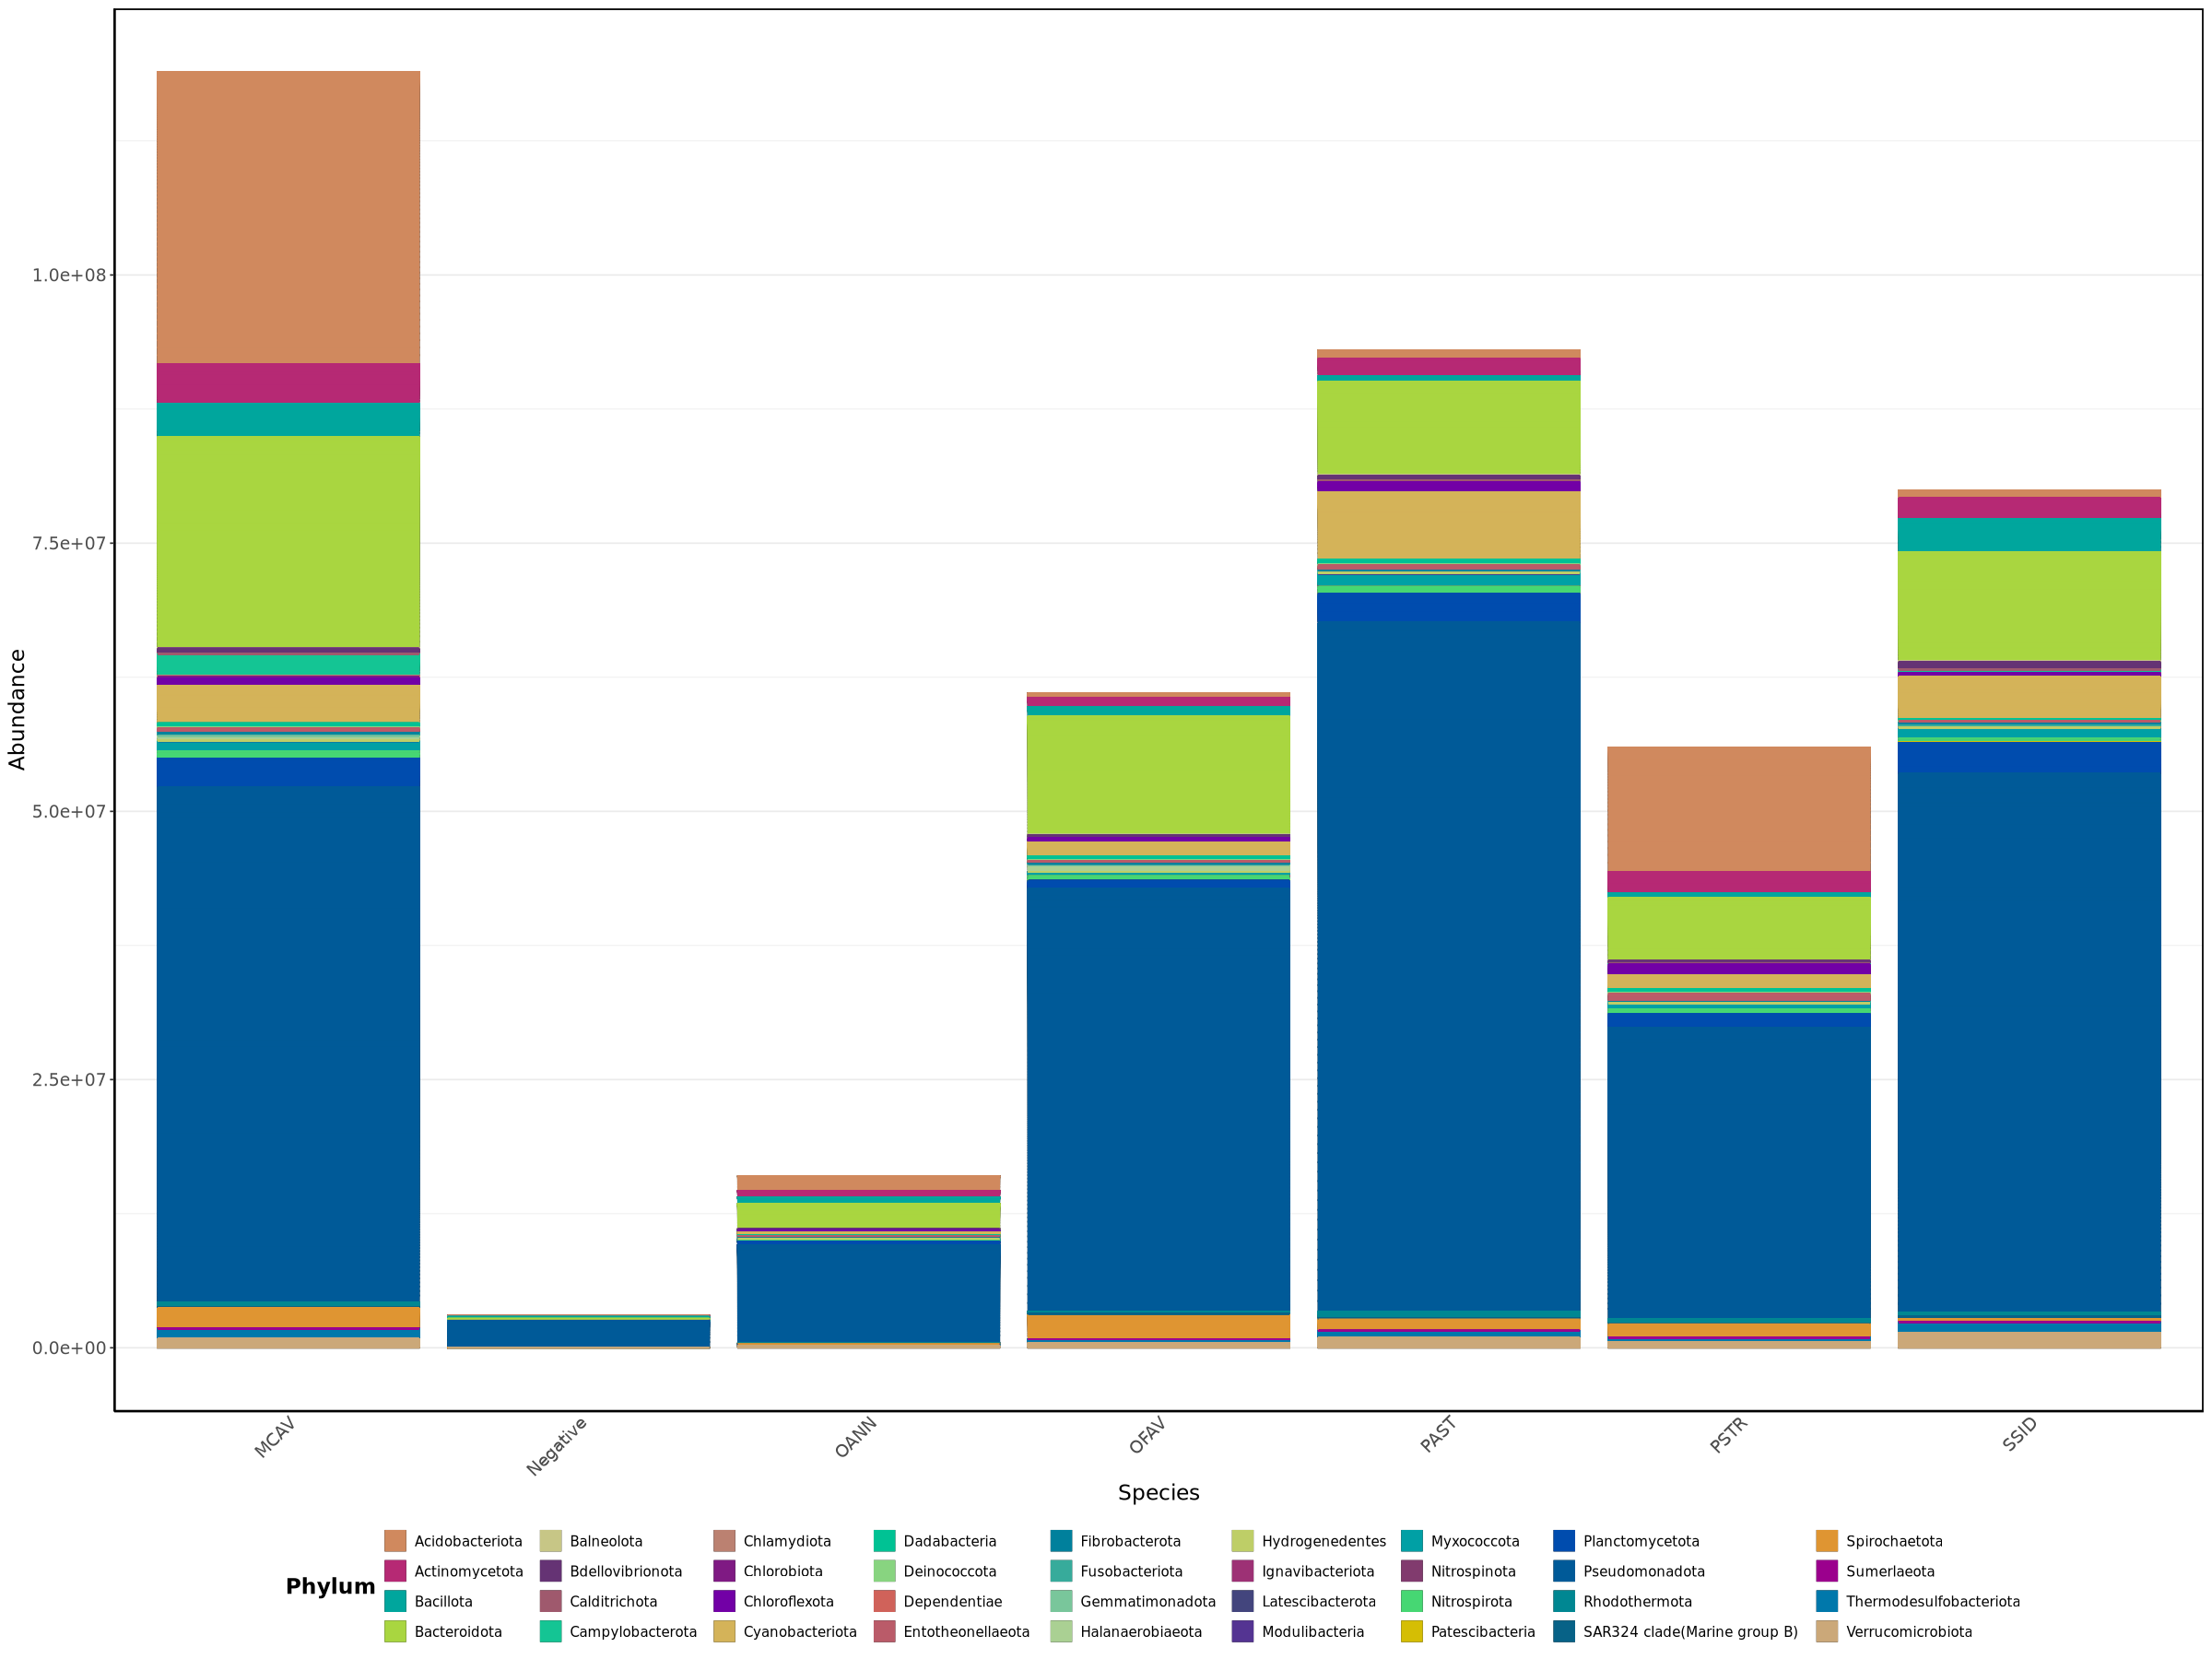

In [163]:
phy37 <- plot_bar(ps_fam300, x = "Species", fill = "Phylum") +
  geom_bar(aes(color = Phylum, fill = Phylum), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = phycolors, drop = TRUE) +
  scale_color_manual(values = phycolors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.5, "cm"),     
    legend.key.height = unit(0.5, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 9, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 9)
  )
phy37 

## create color gradient based on phycolors

In [164]:
# --- 2. Pull Phylum and Family columns as clean data.frame ---
tax_mat <- as.data.frame(tax_table(ps_fam300)[, c("Phylum", "Family")])
tax_mat <- unique(tax_mat[!is.na(tax_mat$Phylum) & !is.na(tax_mat$Family), ])

# Extract as plain character vectors (strips matrix attributes)
all_phyla    <- as.character(tax_mat$Phylum)
all_families <- as.character(tax_mat$Family)

In [165]:
#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

In [166]:
#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [167]:
# --- 3. Build the family_colors vector ---
family_colors <- c()

for (ph in unique(all_phyla)) {
  # Find all unique families belonging to this phylum
  ph_families <- unique(all_families[all_phyla == ph])
  n <- length(ph_families)
  
  if (n > 0) {
    base_col <- phycolors[ph]
    if (is.na(base_col) || is.null(base_col)) base_col <- "#808080" 
    
    # Generate gradient ramps
    light_col <- lighten_color(base_col, 0.4)
    dark_col  <- darken_color(base_col, 0.4) 
    ramp      <- colorRampPalette(c(light_col, base_col, dark_col))(n)
    
    # Name vector elements directly by Family name
    names(ramp) <- ph_families
    family_colors <- c(family_colors, ramp)
  }
}

In [168]:
head(family_colors)

Vibrionaceae Endozoicomonadaceae    Terasakiellaceae    Methylophagaceae 
          "#669CC1"           "#649AC0"           "#6299BF"           "#6098BE" 
  Alcanivoracaceae1        SAR116 clade 
          "#5F97BE"           "#5D96BD"

In [169]:
length(family_colors)

[1] 300

In [170]:
# plot sizing
options(repr.plot.width=20, repr.plot.height=15)

## top 300 family plot
- we can see that a majority of families are from Pseudomonadota because they are the peachy color

In [171]:
#confirm that it has been reduced
length(unique(tax_table(ps_fam300)[, "Family"]))

[1] 296

### colors
- use family_colors

### 300plot

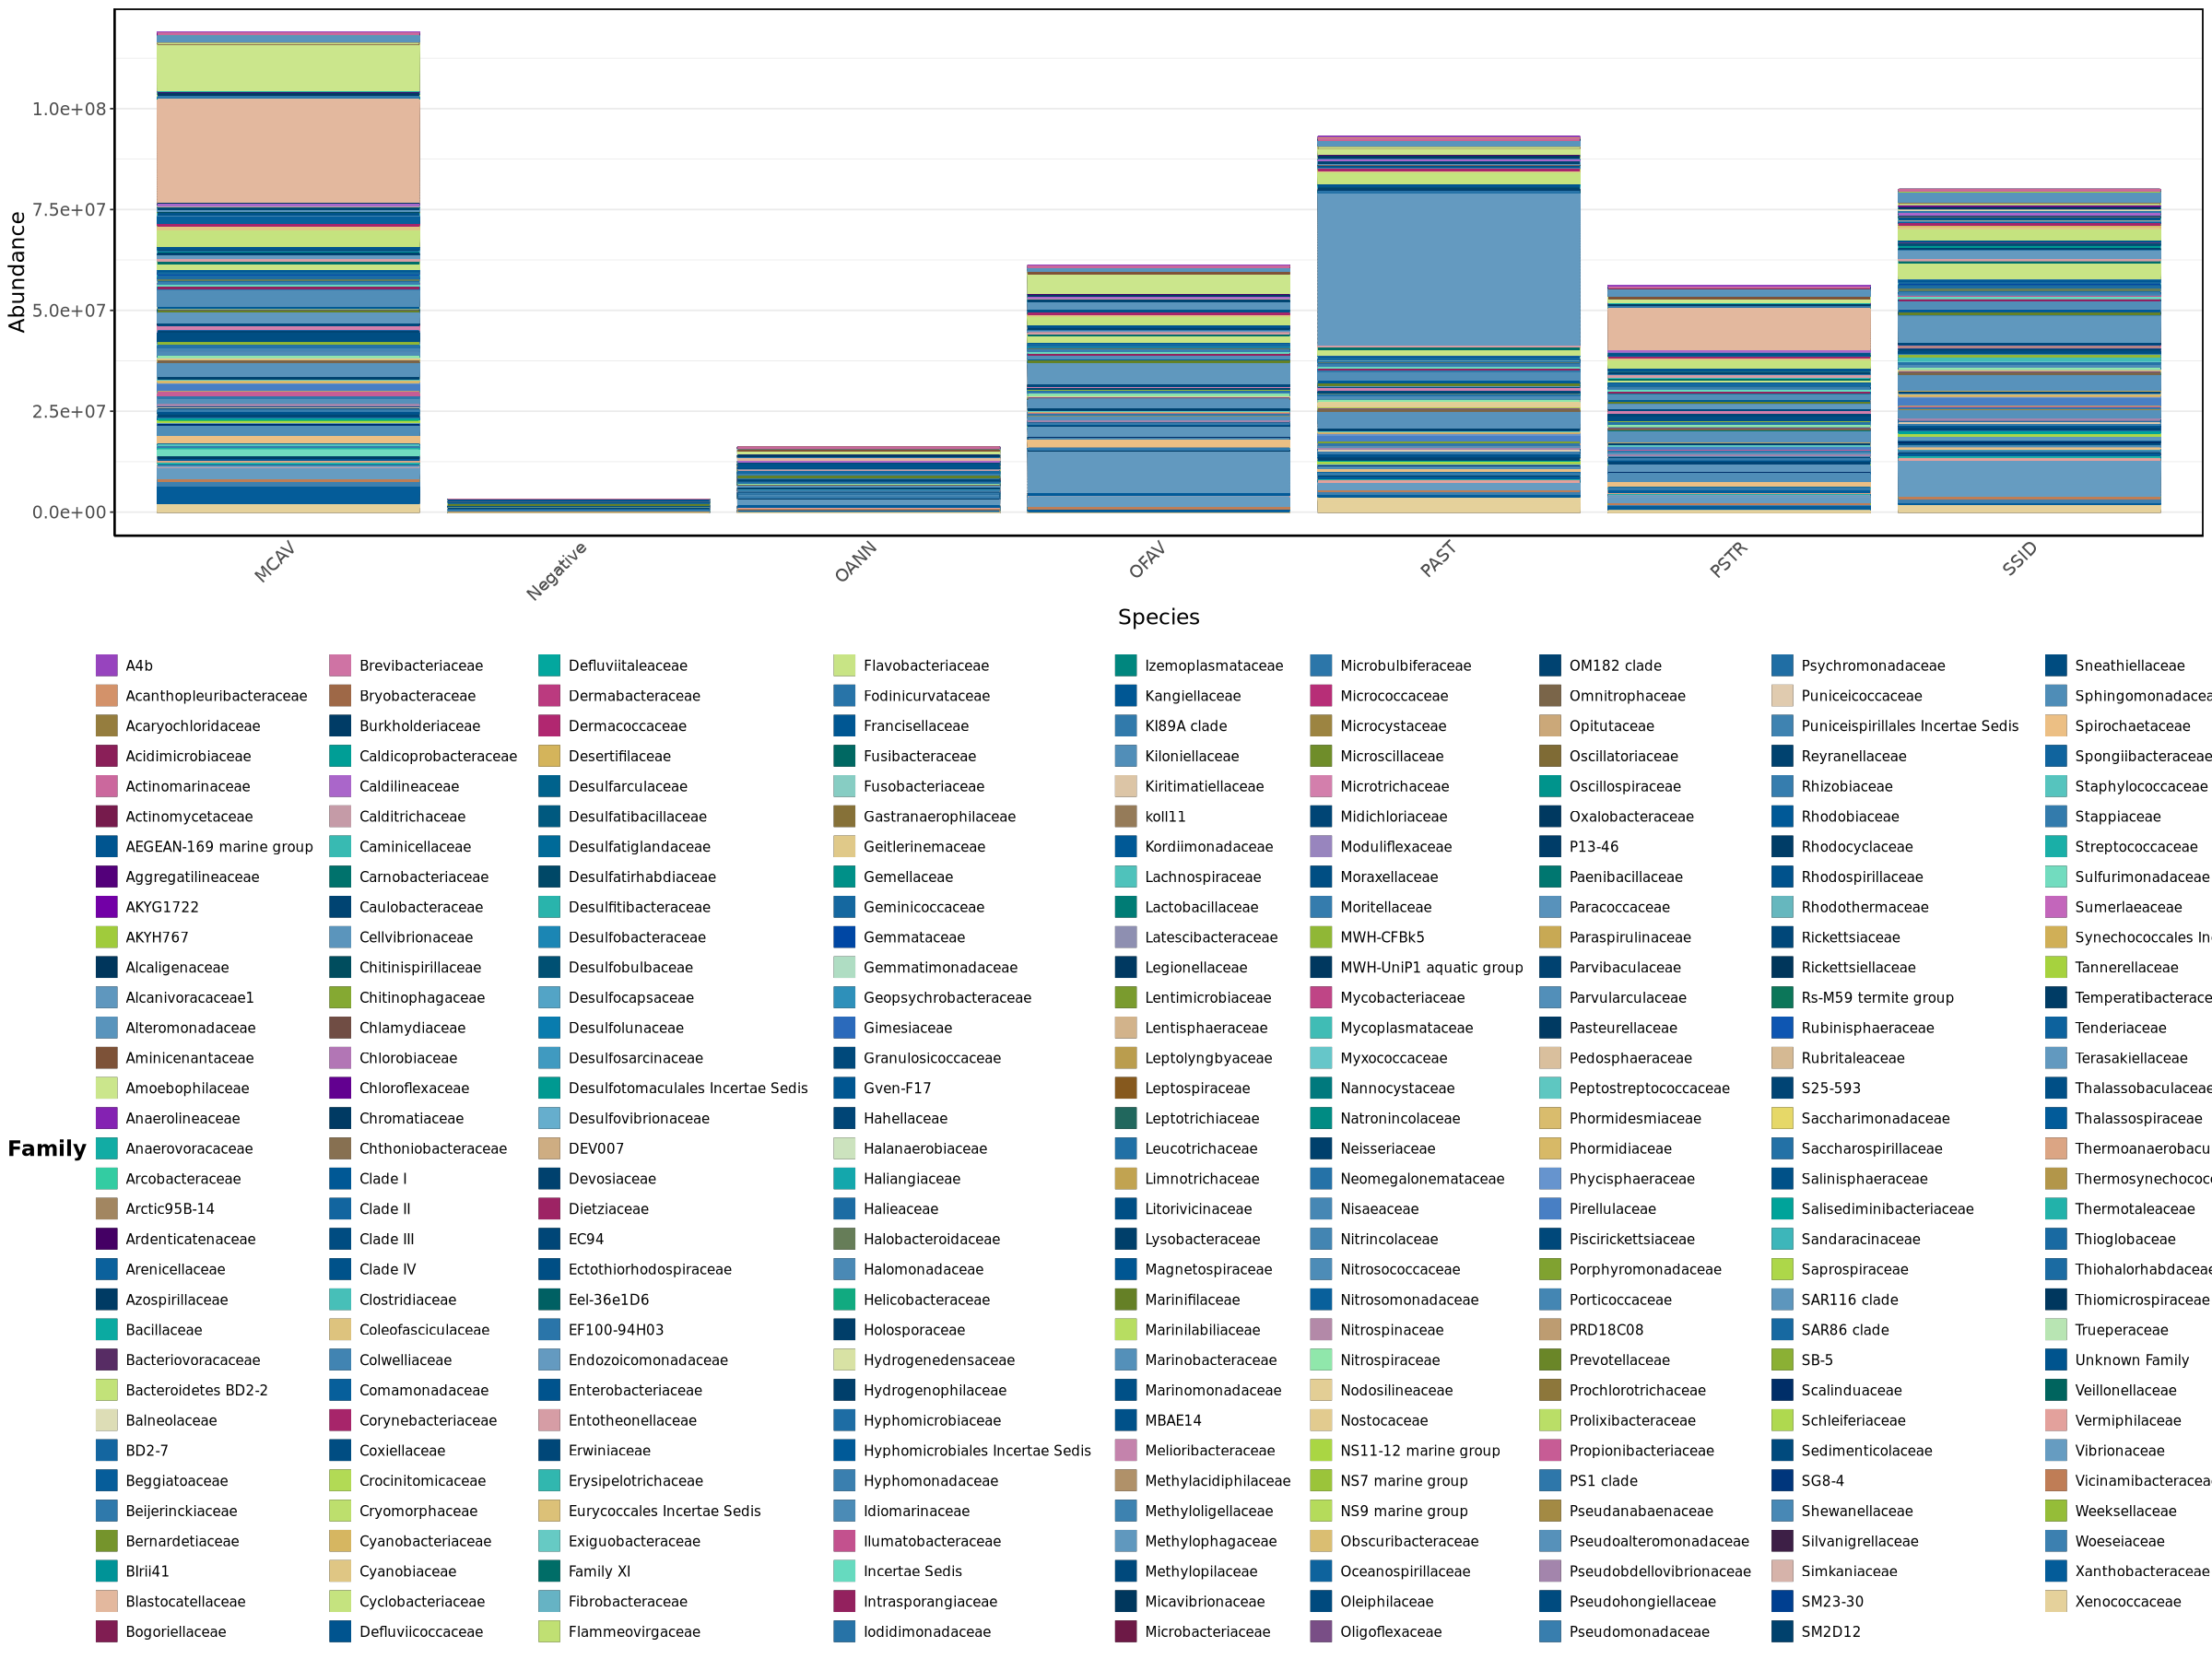

In [172]:
fam_300 <- plot_bar(ps_fam300, x = "Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_color_manual(values = family_colors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.5, "cm"),     
    legend.key.height = unit(0.5, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 9, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 9)
  )

fam_300

## top 100

In [173]:
#isolating top 50 family taxa
top100<- names(sort(taxa_sums(ps_fam300), decreasing=TRUE))[1:100] 
ps_fam100 <- prune_taxa(top100, ps_fam300) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam100)[, "Family"]))

[1] 99

### family_colors plot

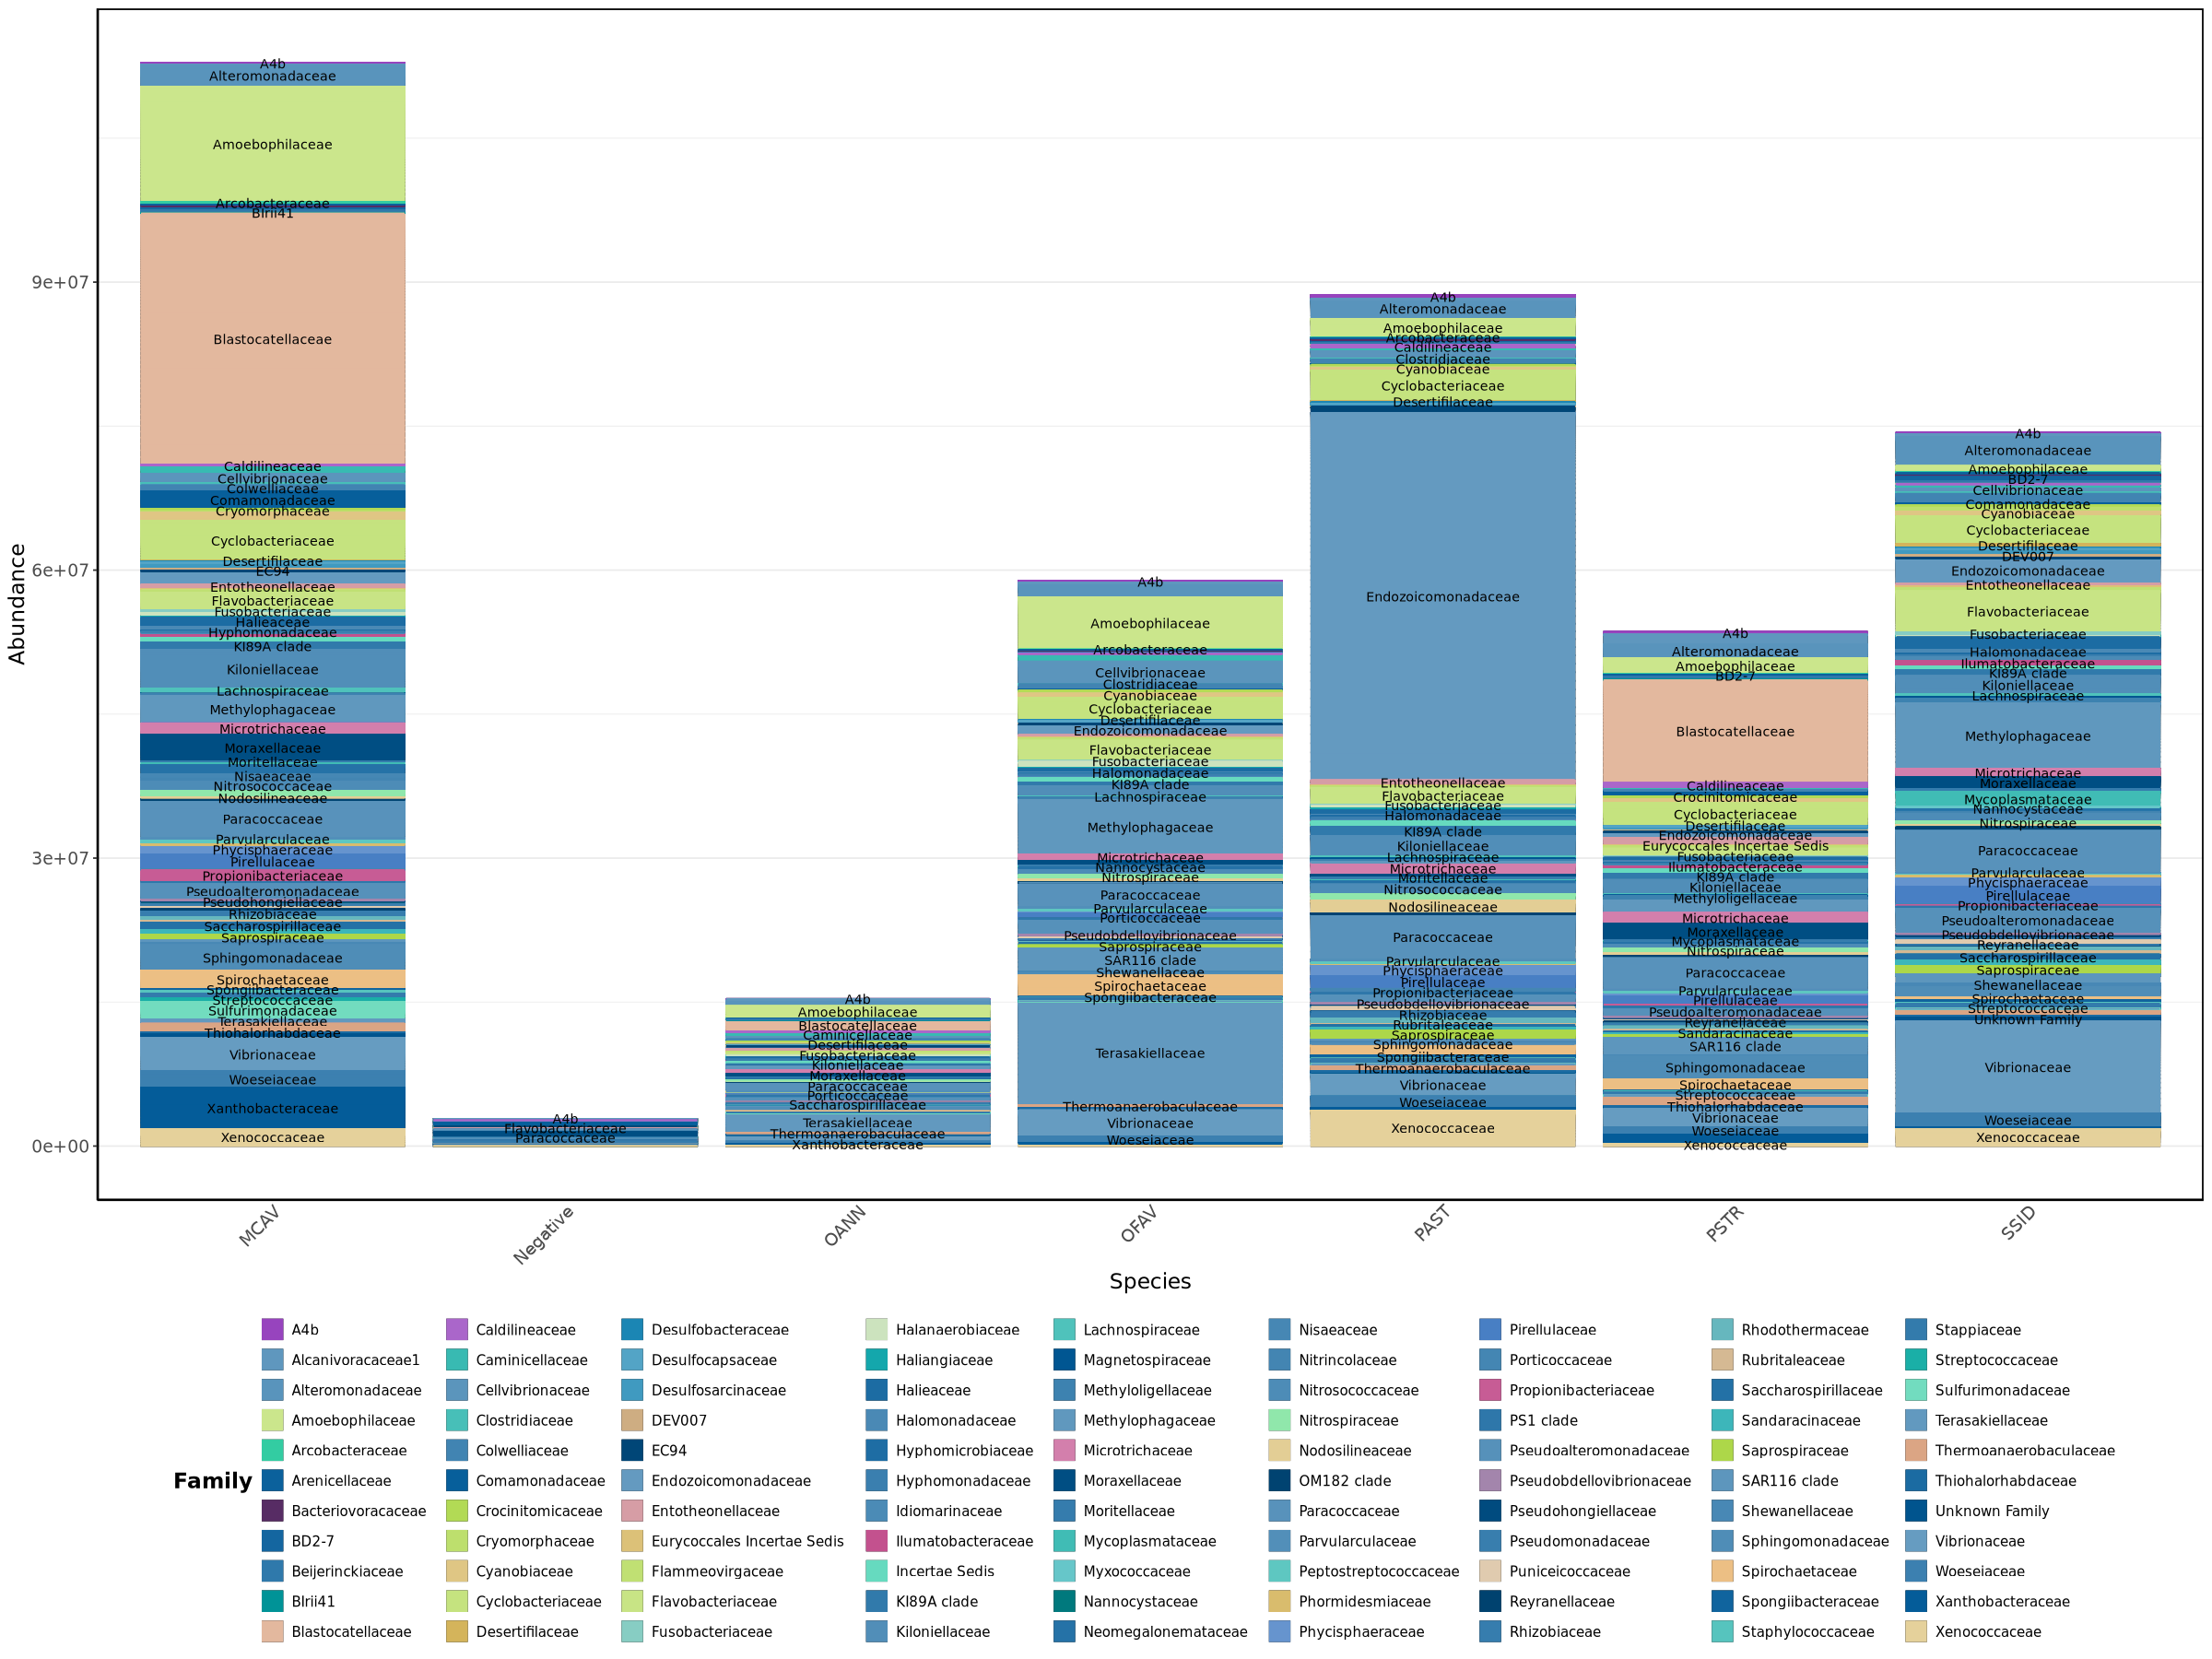

In [174]:
#plot
fam_100 <- plot_bar(ps_fam100, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
# --- REPLACED geom_text WITH stat_summary ---
  stat_summary(
    aes(label = Family, group = Family),
    fun = sum,
    geom = "text",
    position = position_stack(vjust = 0.5),
    color = "black", 
    size = 3, 
    check_overlap = TRUE
  ) +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_color_manual(values = family_colors, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.5, "cm"),     
    legend.key.height = unit(0.5, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 9, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 9)
  )
fam_100

## new colors based on ps_fam100

In [181]:
### ps_fam100 colors

# --- 1. Get unique family cleanly as character strings ---
fam_100 <- as.character(unique(tax_table(ps_fam100)[, "Family"]))

# Generate 36 distinct HCL color hex codes
colors_100 <- hcl(
  h = seq(15, 375, length.out = 100 + 1)[1:100], 
  c = 100, 
  l = 65
)

# Shuffle reproducibly so adjacent taxonomy levels aren't similar shades
set.seed(6)
colors_100 <- sample(colors_100)

# Assign names
names(colors_100) <- fam_100

### new colors plot

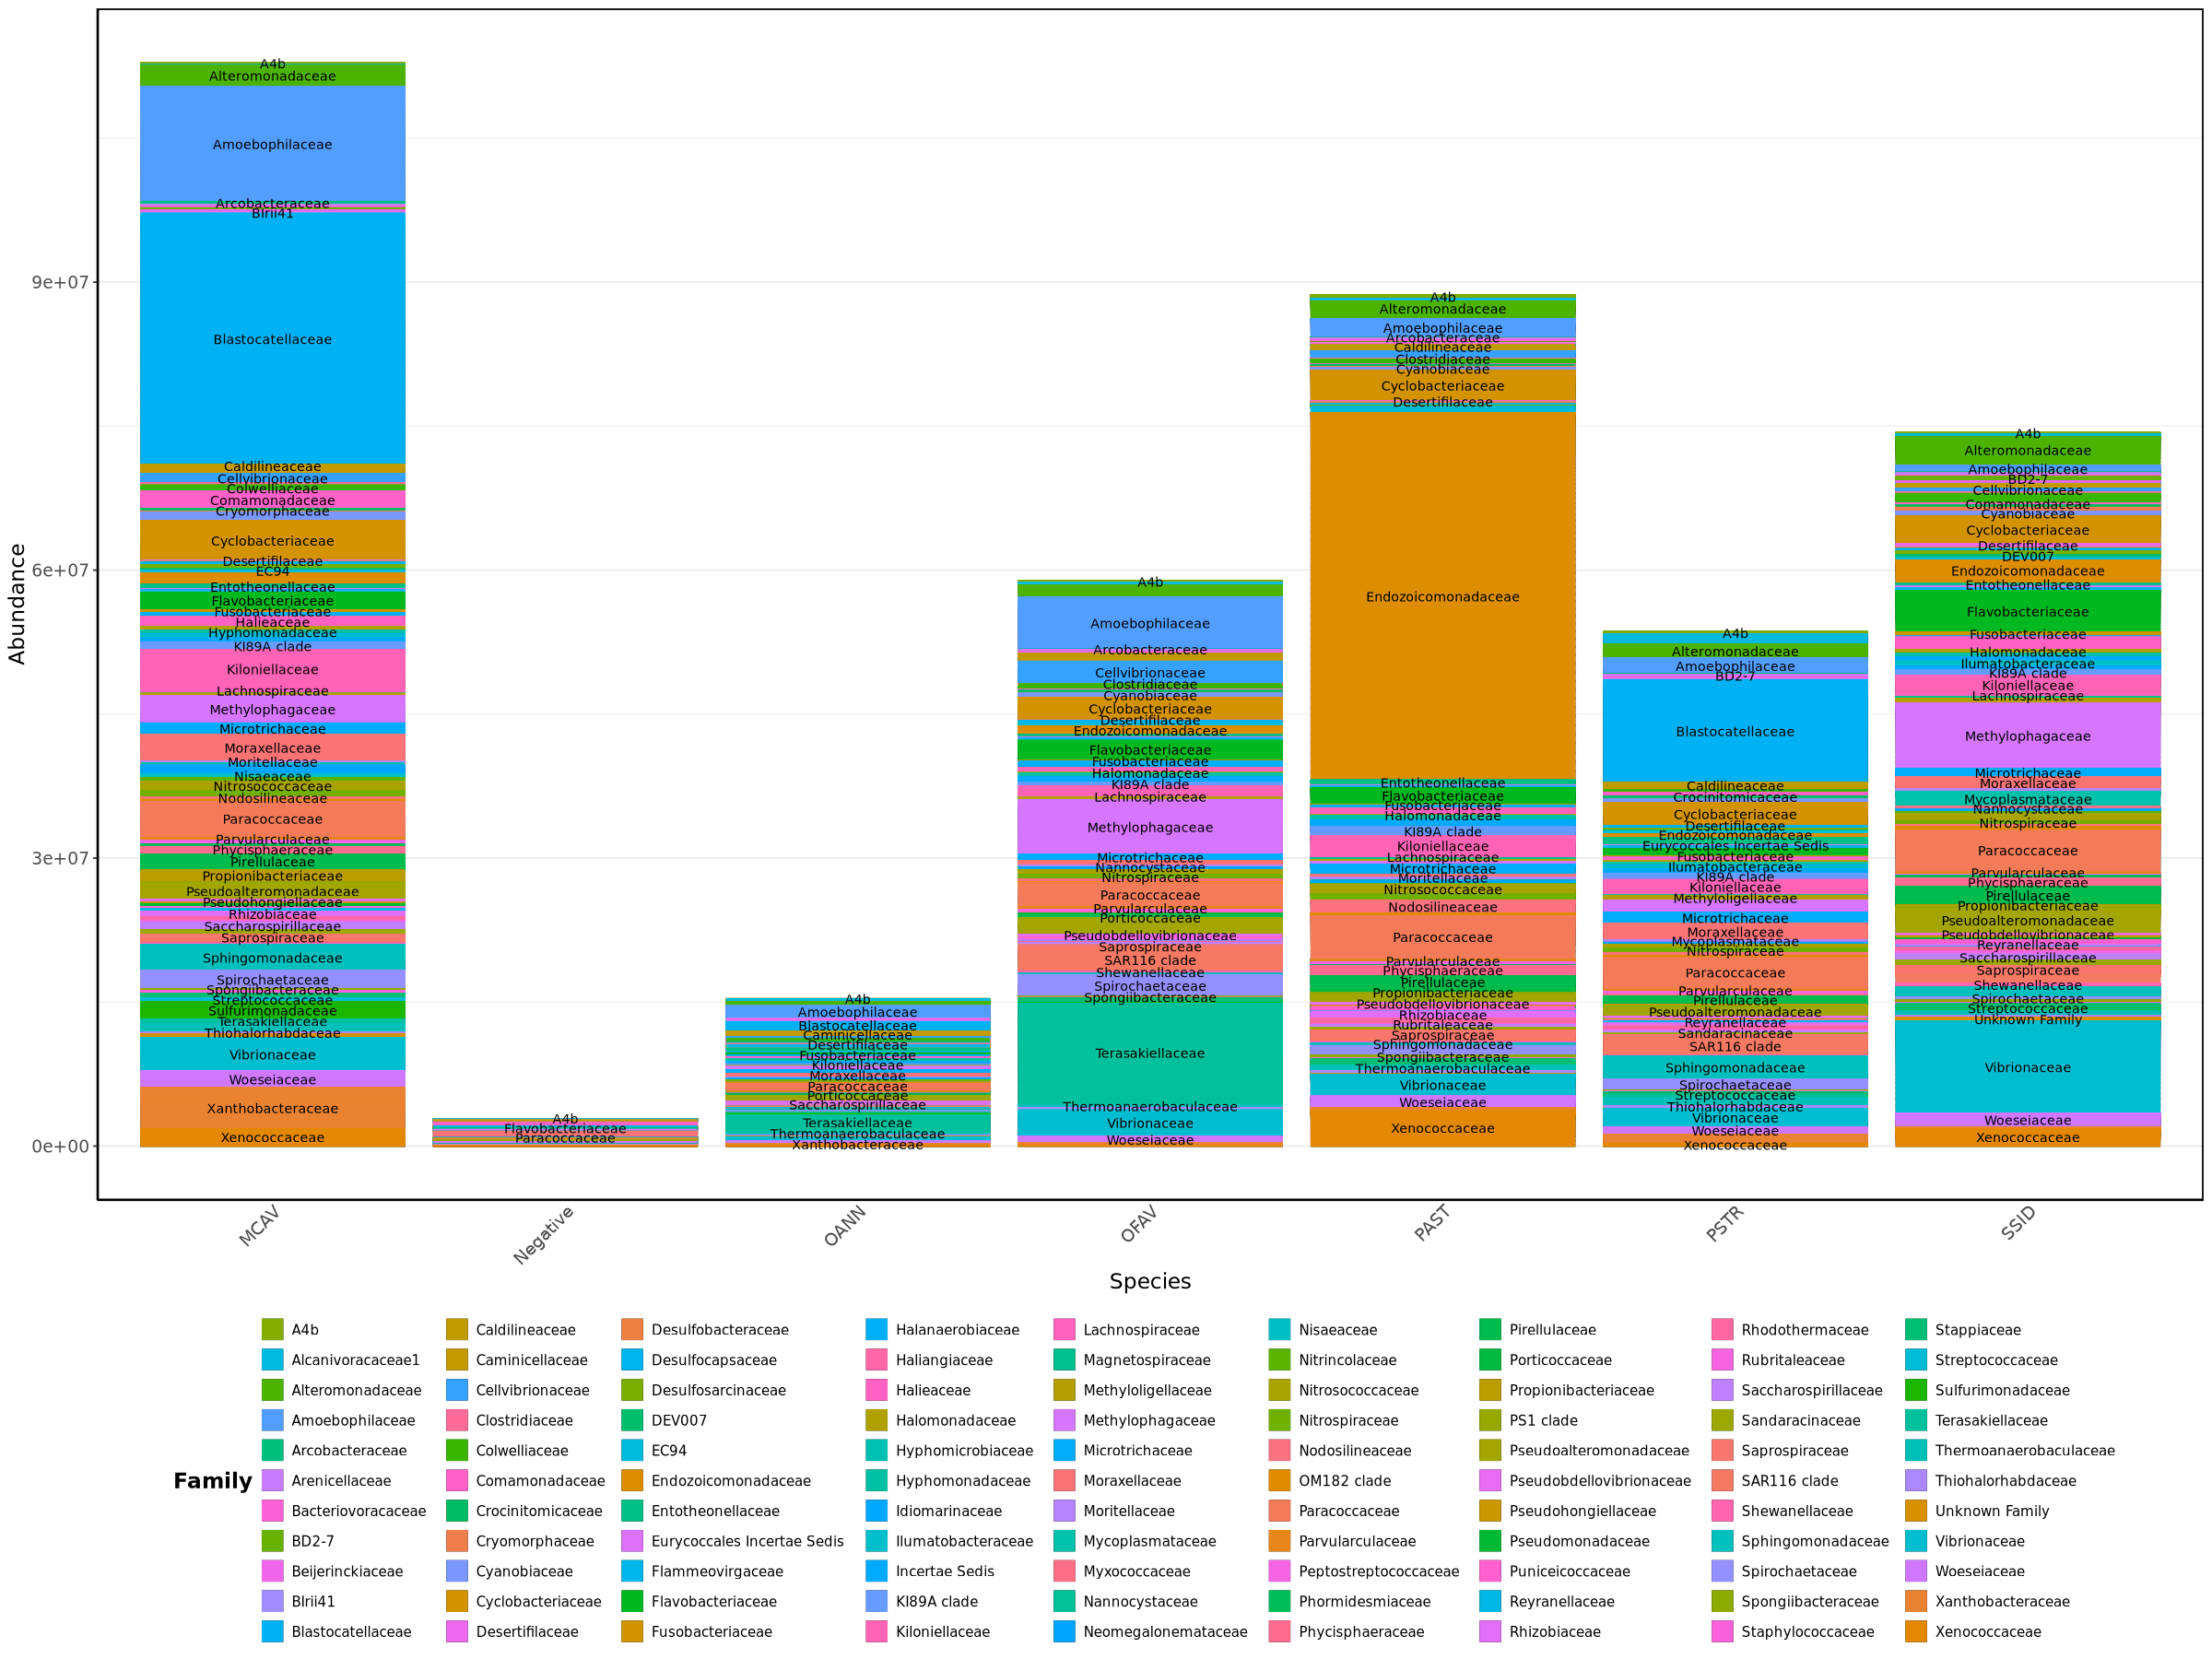

In [182]:
#plot
fam_100 <- plot_bar(ps_fam100, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
# --- REPLACED geom_text WITH stat_summary ---
  stat_summary(
    aes(label = Family, group = Family),
    fun = sum,
    geom = "text",
    position = position_stack(vjust = 0.5),
    color = "black", 
    size = 3, 
    check_overlap = TRUE
  ) +
  scale_fill_manual(values = colors_100, drop = TRUE) +
  scale_color_manual(values = colors_100, drop = TRUE) +
  theme_bw() +
  theme(
    # Move legend to the bottom so the plot gets maximum width
    legend.position = "bottom",
    legend.box = "horizontal",
    
    # Scale down text & key sizes so it doesn't crowd out the plot vertically
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 9),
    legend.key.width = unit(0.5, "cm"),     
    legend.key.height = unit(0.5, "cm"),   
    
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 14)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 9, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 9)
  )
fam_100

## top 50

In [183]:
#isolating top 50 family taxa
top50<- names(sort(taxa_sums(ps_fam300), decreasing=TRUE))[1:50] 
ps_fam50 <- prune_taxa(top50, ps_fam300) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam50)[, "Family"]))

[1] 50

## top 50 color palette based on phylum

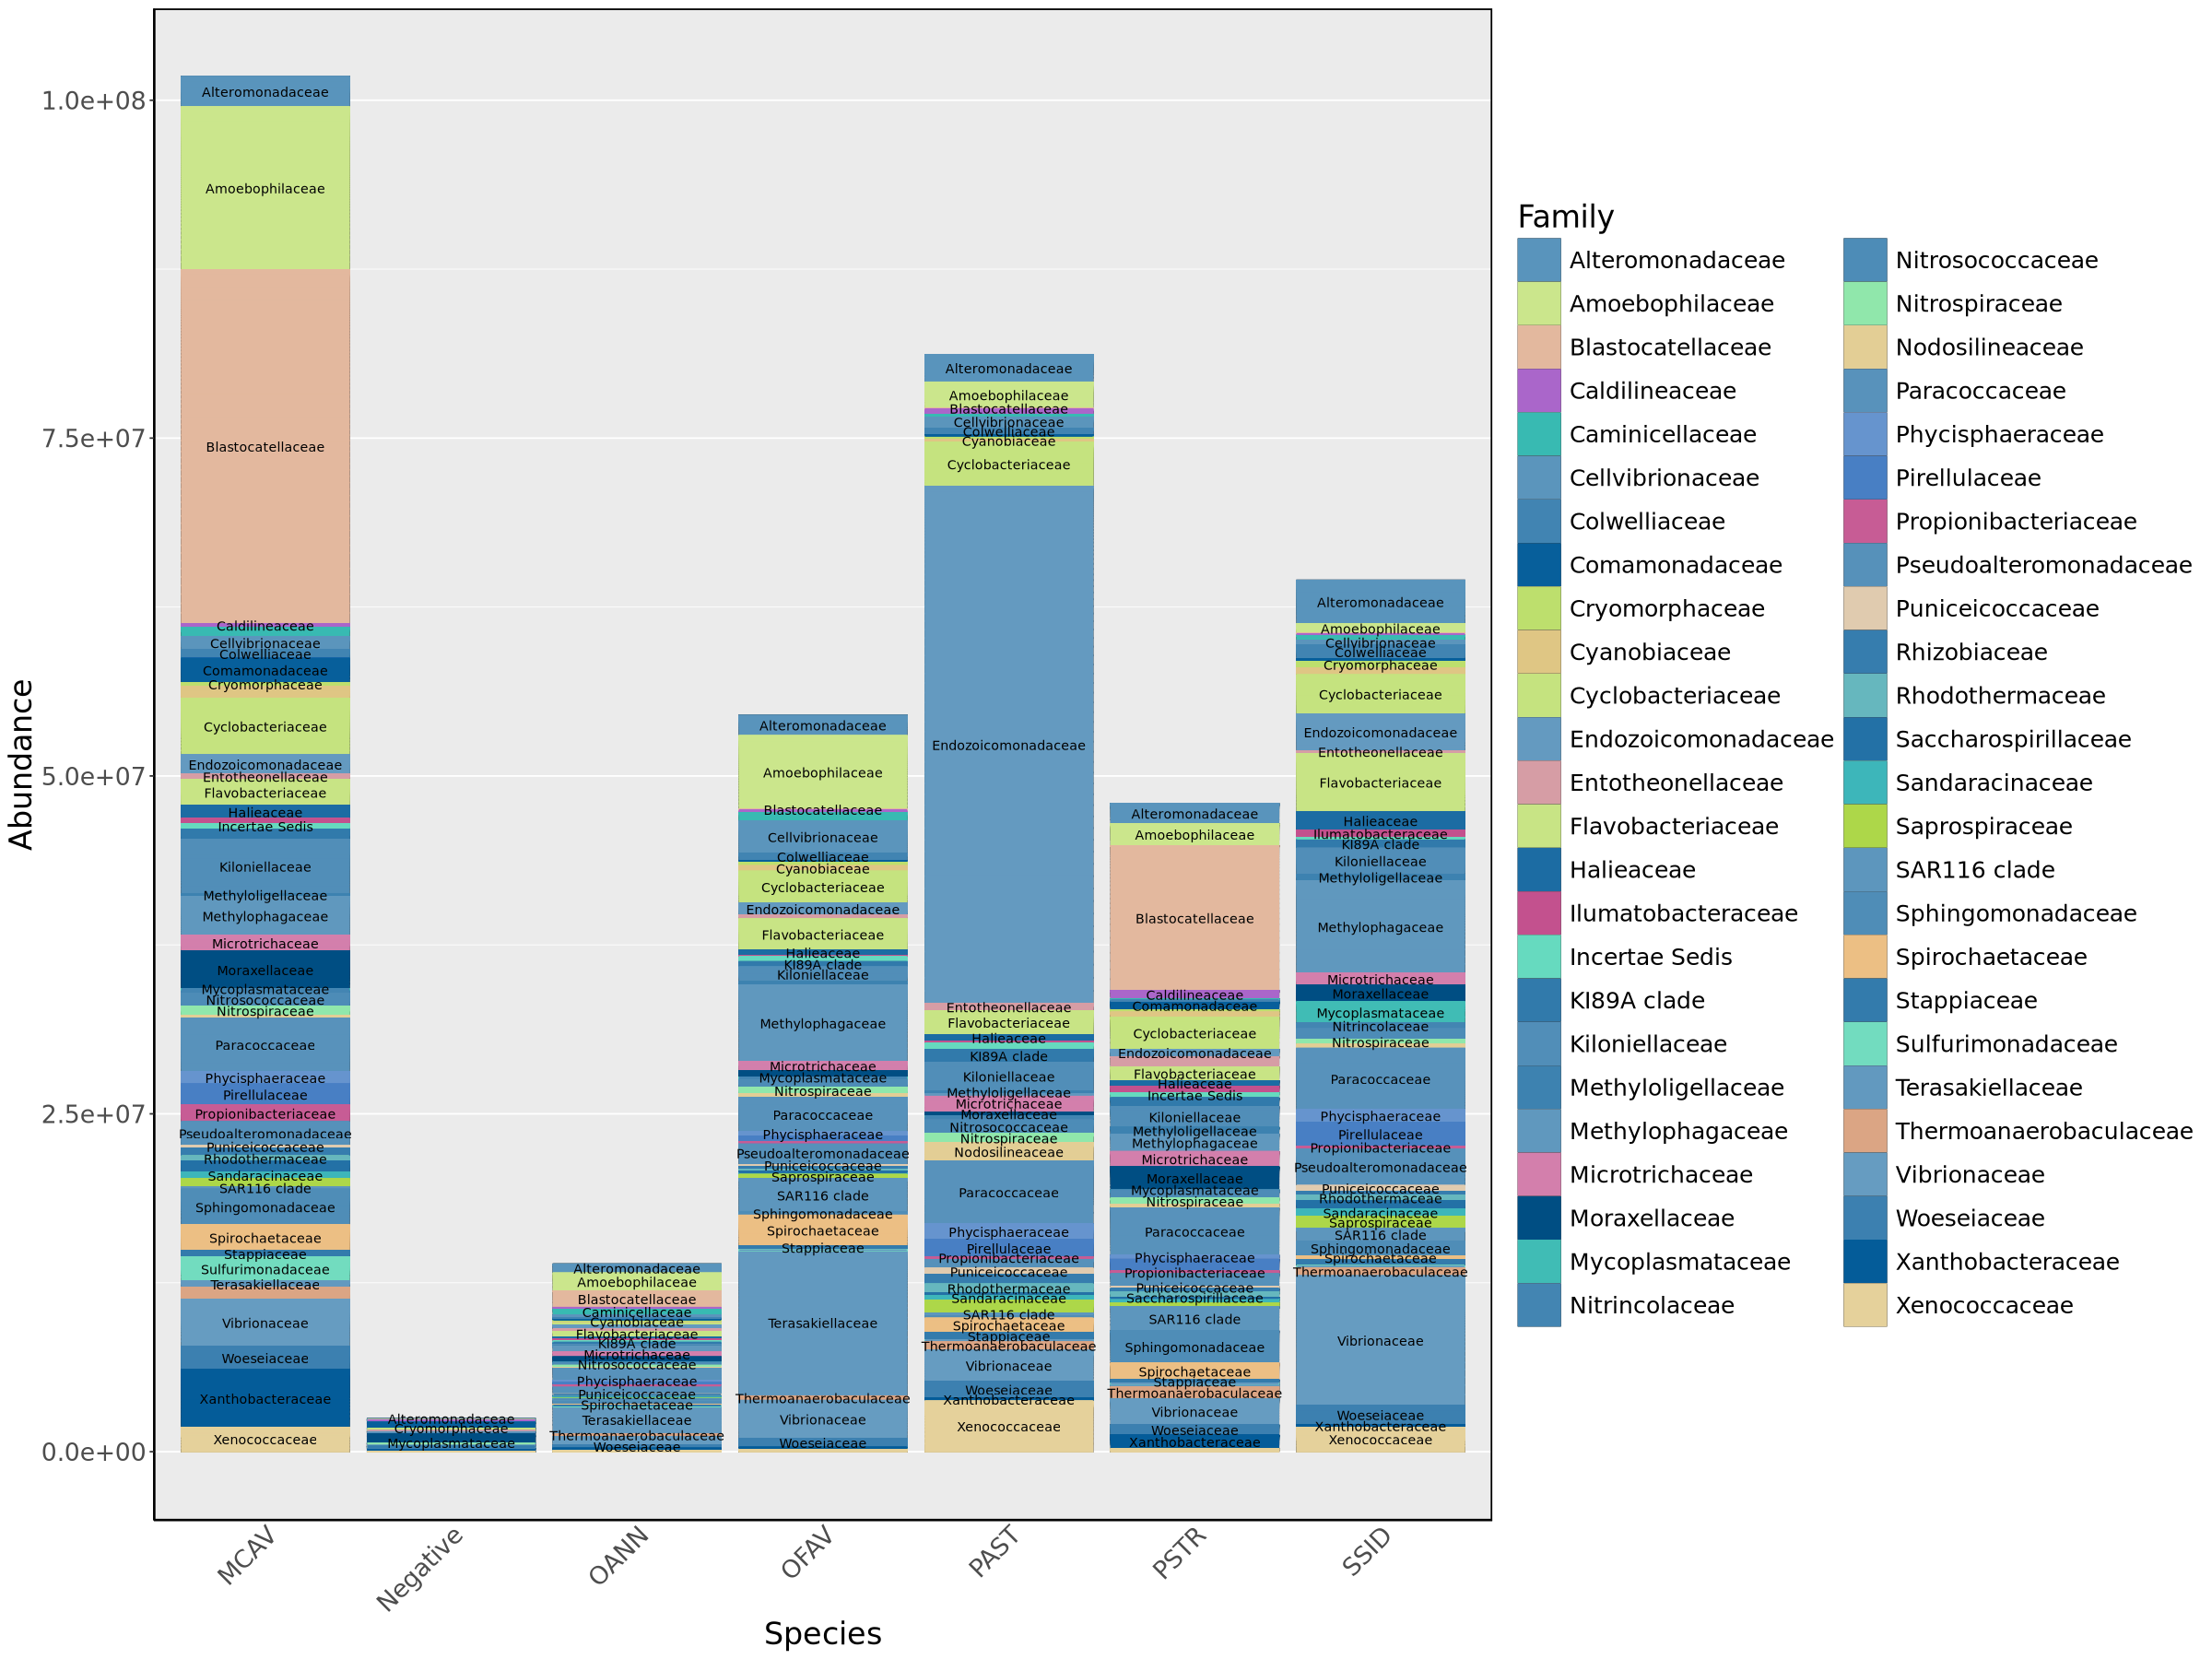

In [184]:
#plot
phy_fam_50 <- plot_bar(ps_fam50, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
# --- REPLACED geom_text WITH stat_summary ---
  stat_summary(
    aes(label = Family, group = Family),
    fun = sum,
    geom = "text",
    position = position_stack(vjust = 0.5),
    color = "black", 
    size = 3, 
    check_overlap = TRUE
  ) +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_color_manual(values = family_colors, drop = TRUE) +
theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.0, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.0, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 2, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 2)
  )
phy_fam_50

## top 50 new color palette

### colors 
- use family_colors

In [185]:
num50_colors <- length(unique(tax_table(ps_fam50)[, "Family"]))

# 1. Combine several distinct pallettes to make 66 colors
big_palette <- c(
  brewer.pal(9, "Set1"),
  brewer.pal(12, "Set3"),
  brewer.pal(8, "Dark2"), 
  brewer.pal(12, "Paired"),
  brewer.pal(9, "Pastel1"),
  brewer.pal(8, "Set2"),
  brewer.pal(8, "Accent")  
)

# 2. Take only what you need, and shuffle them to separate similar shades
set.seed(42) # Set a seed so your "random" shuffle is reproducible every time you knit
colors_50 <- sample(big_palette, num50_colors)

# 3. Name them
names(colors_50) <- unique(tax_table(ps_fam50)[, "Family"]) #telling ggplot exactly which fam gets which color

In [186]:
head(colors_50)

Vibrionaceae Endozoicomonadaceae    Terasakiellaceae    Methylophagaceae 
          "#FDDAEC"           "#BF5B17"           "#E7298A"           "#8DD3C7" 
  Blastocatellaceae     Amoebophilaceae 
          "#FDBF6F"           "#D9D9D9"

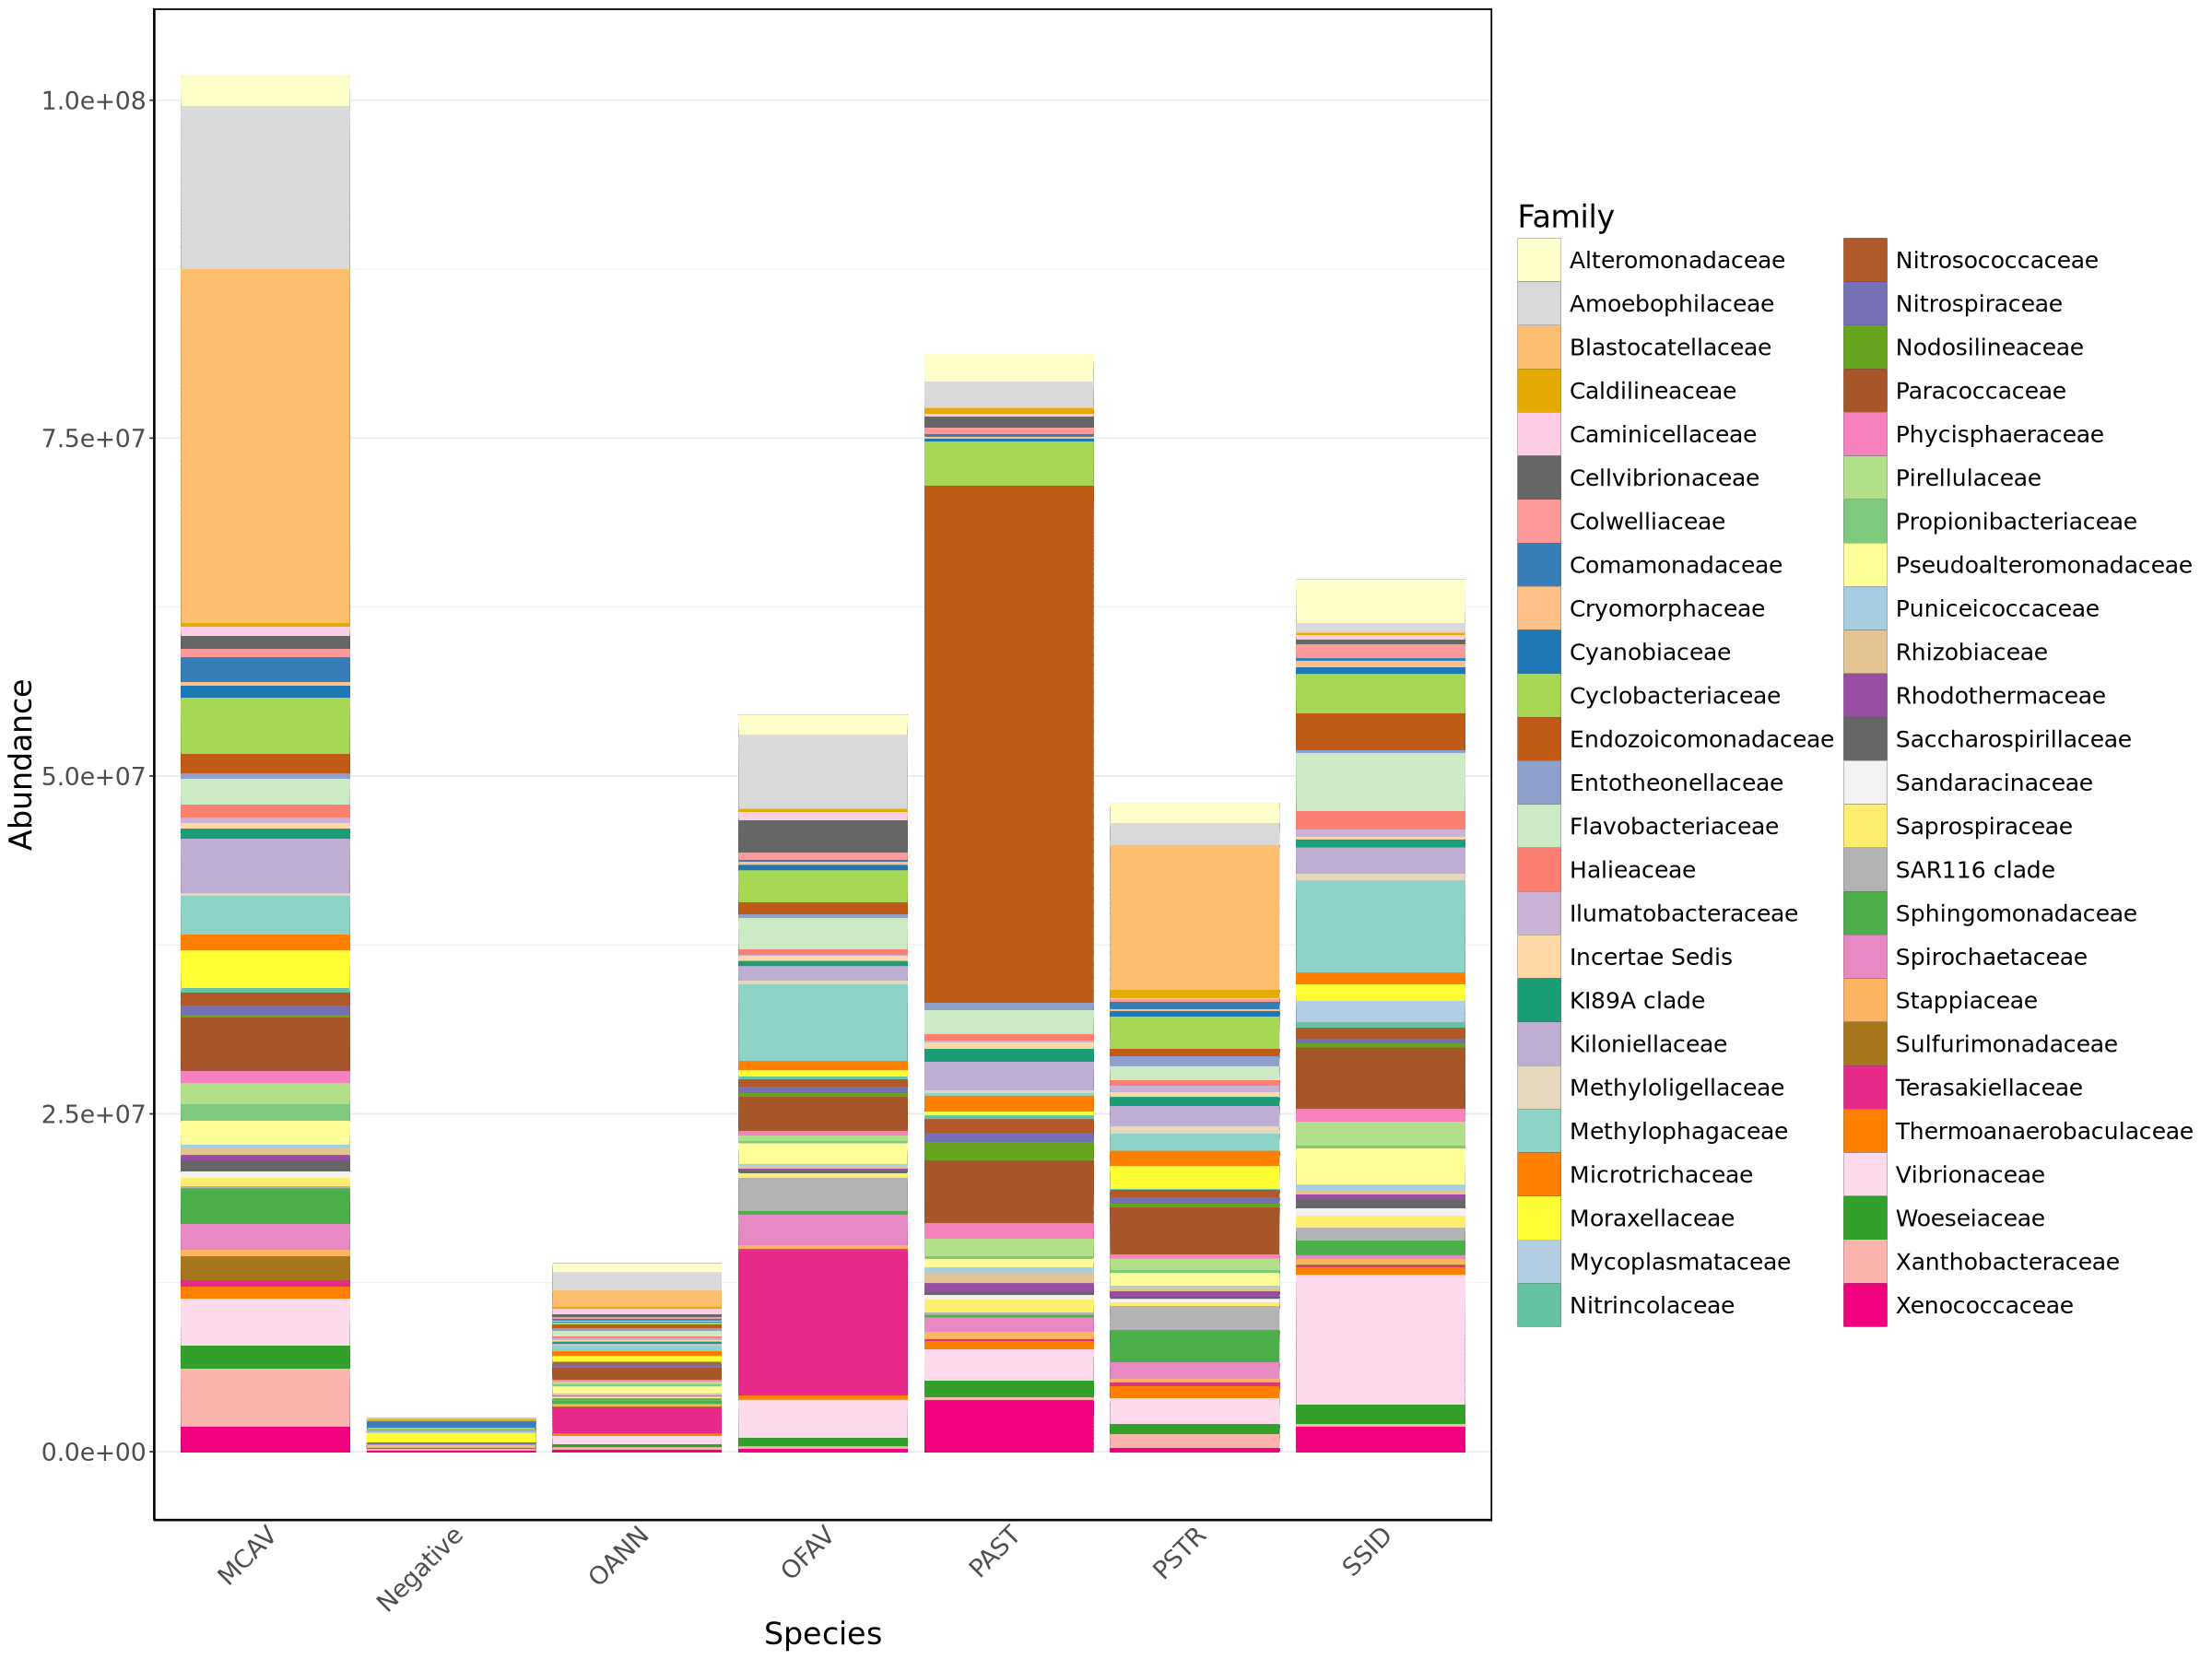

In [187]:
#plot
fam_50 <- plot_bar(ps_fam50, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = colors_50, drop = TRUE) +
  scale_color_manual(values = colors_50, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.0, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.0, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 2, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 2)
  )
fam_50

## top 28

In [188]:
#isolating top 25 family taxa
top28<- names(sort(taxa_sums(ps_fam300), decreasing=TRUE))[1:28] 
ps_fam28 <- prune_taxa(top28, ps_fam300) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam28)[, "Family"]))

[1] 28

## family_colors

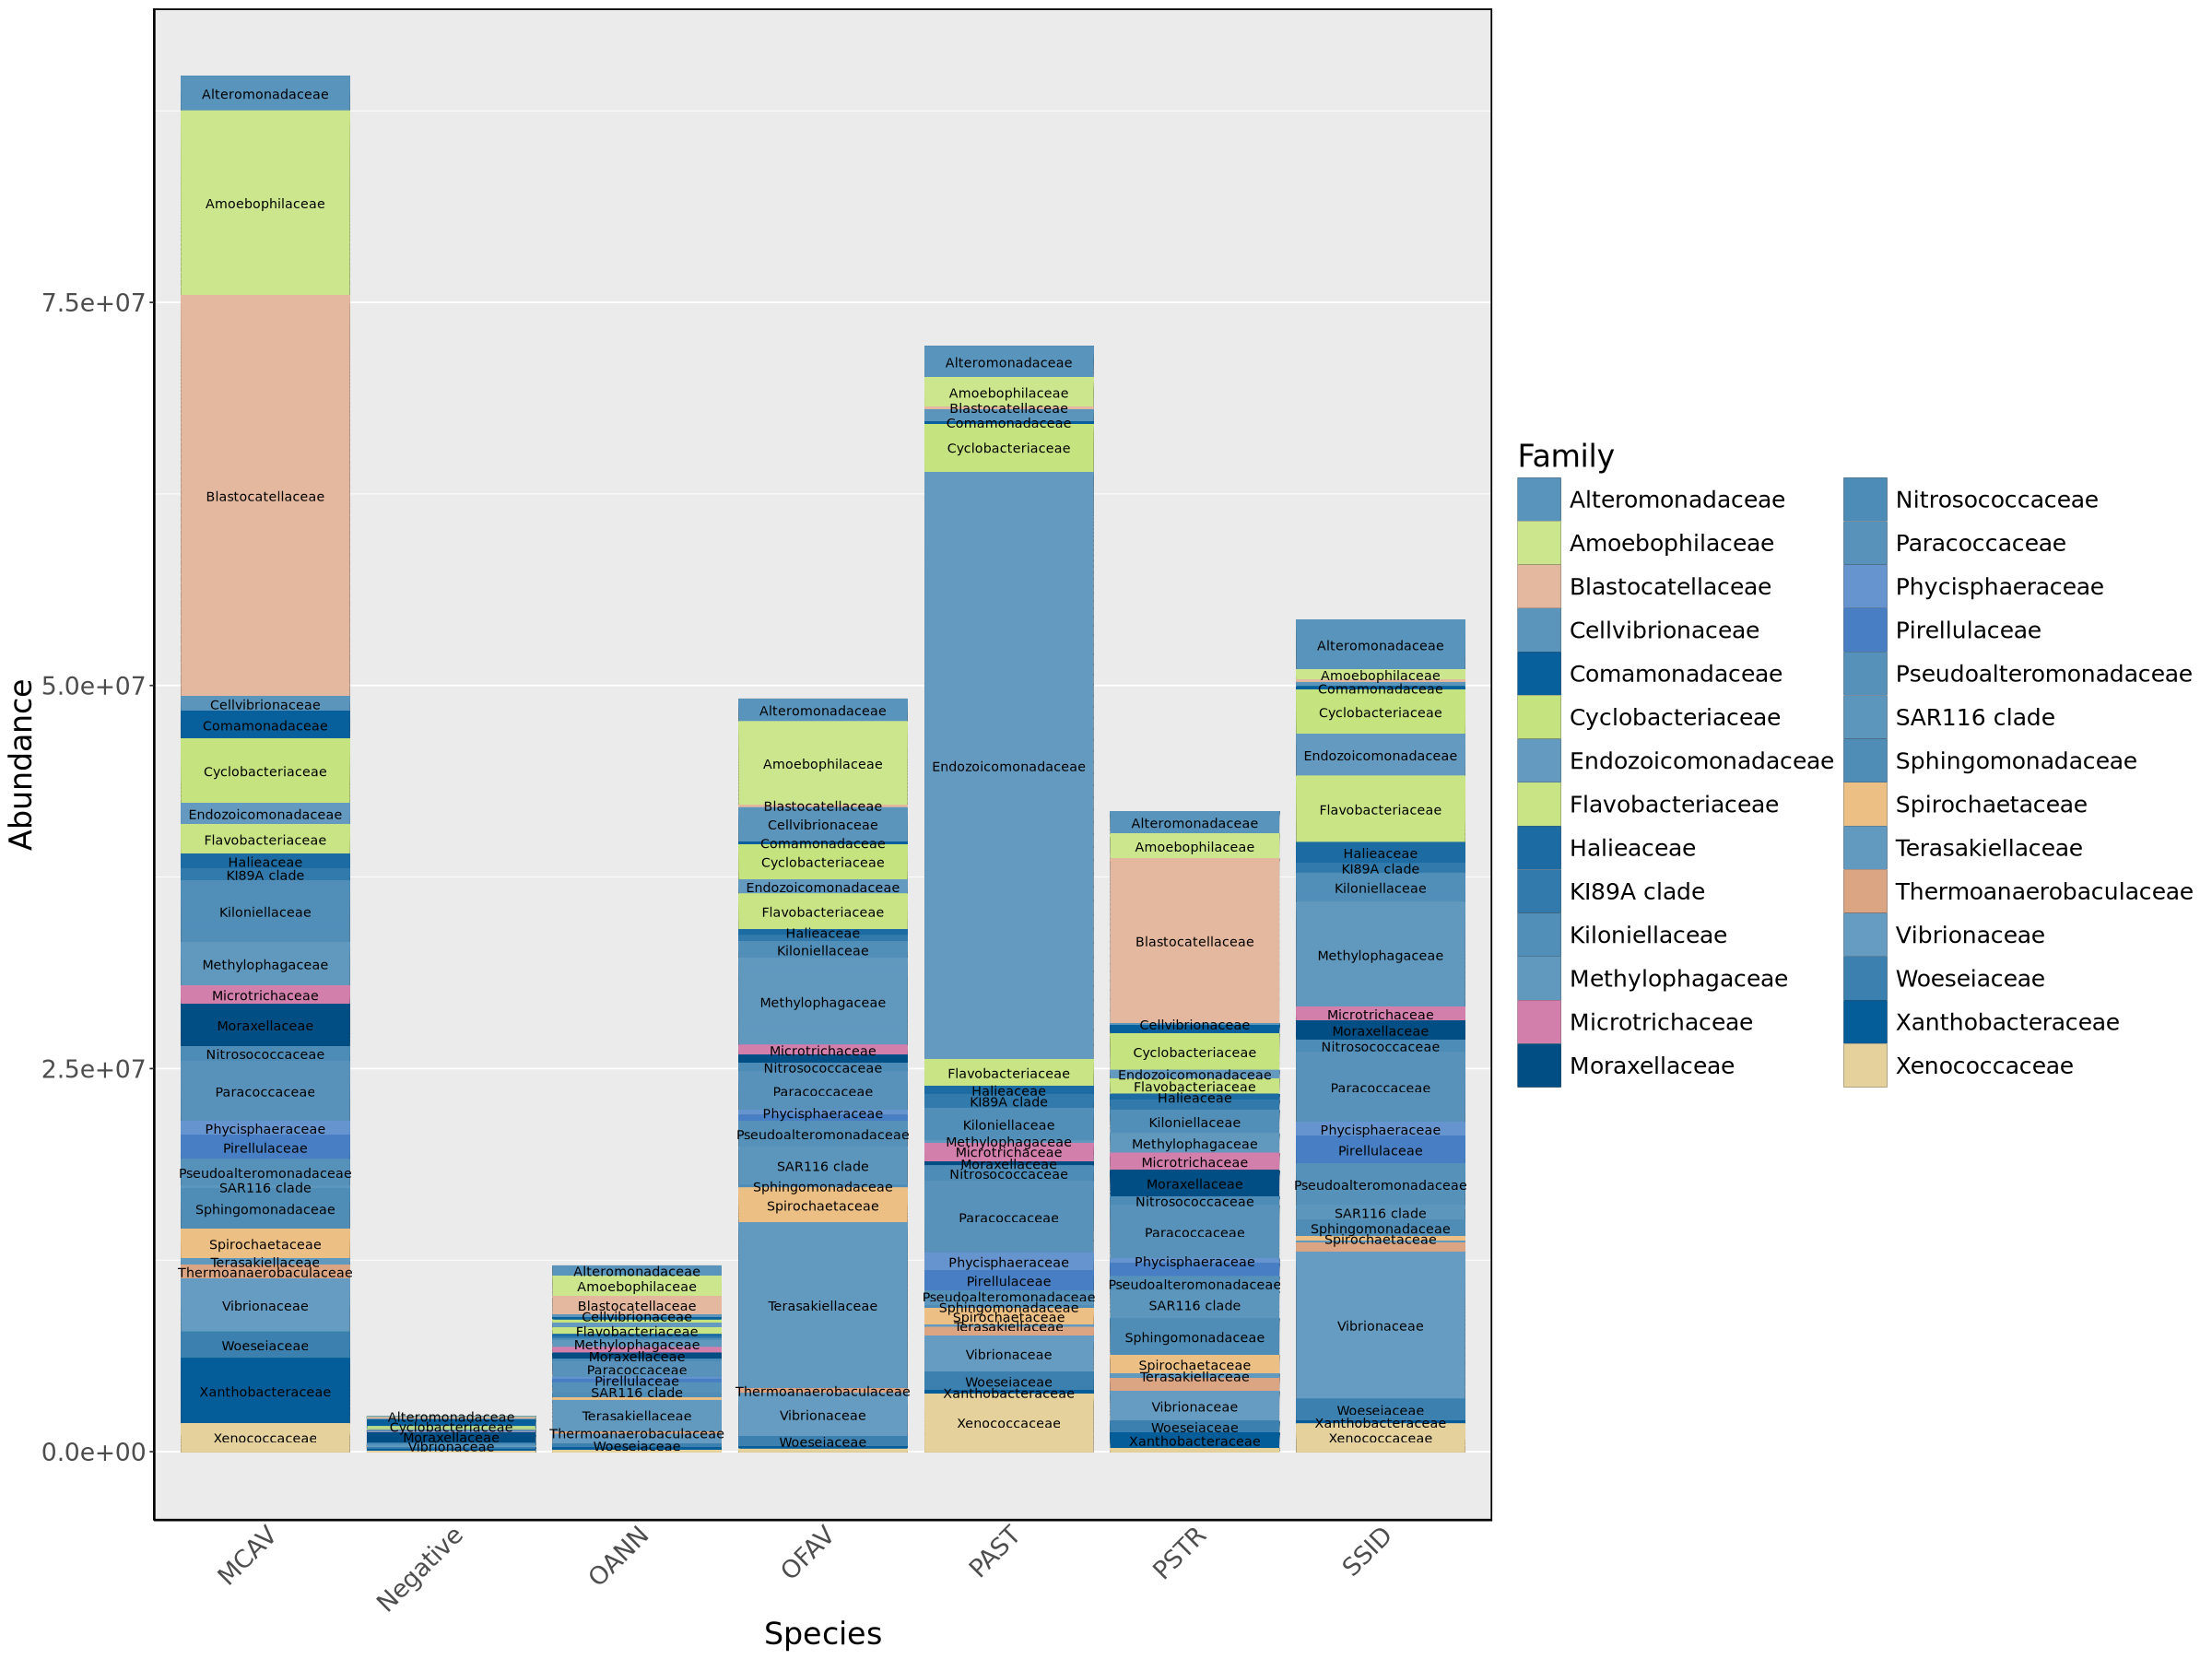

In [189]:
#plot
phy_fam_28 <- plot_bar(ps_fam28, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
# --- REPLACED geom_text WITH stat_summary ---
  stat_summary(
    aes(label = Family, group = Family),
    fun = sum,
    geom = "text",
    position = position_stack(vjust = 0.5),
    color = "black", 
    size = 3, 
    check_overlap = TRUE
  ) +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_color_manual(values = family_colors, drop = TRUE) +
theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.0, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.0, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  ) +
  # Force the legend items into 5–6 columns to save vertical space
  guides(
    fill = guide_legend(ncol = 2, override.aes = list(linewidth = 0.2)),
    color = guide_legend(ncol = 2)
  )
phy_fam_28

## new colors

In [190]:
num28_colors <- length(unique(tax_table(ps_fam28)[, "Family"]))

# 1. Combine several distinct qualitative palettes
palette_28 <- c(
  brewer.pal(8, "Set1"),
  brewer.pal(12, "Set3"),
  brewer.pal(8, "Dark2")
)

# 2. Take only what you need, and shuffle them to separate similar shades
set.seed(42) # Set a seed so your "random" shuffle is reproducible every time you knit
colors_28 <- sample(palette_28, num28_colors)

# 3. Name them
names(colors_28) <- unique(tax_table(ps_fam28)[, "Family"]) #telling ggplot exactly which fam gets which color

### all species, use this plot to get the full legend 28 Family Taxa
- not all 28 show up in each species plot
- also make sure contamination isn't a problem with negatives

### top 28 new colors plot

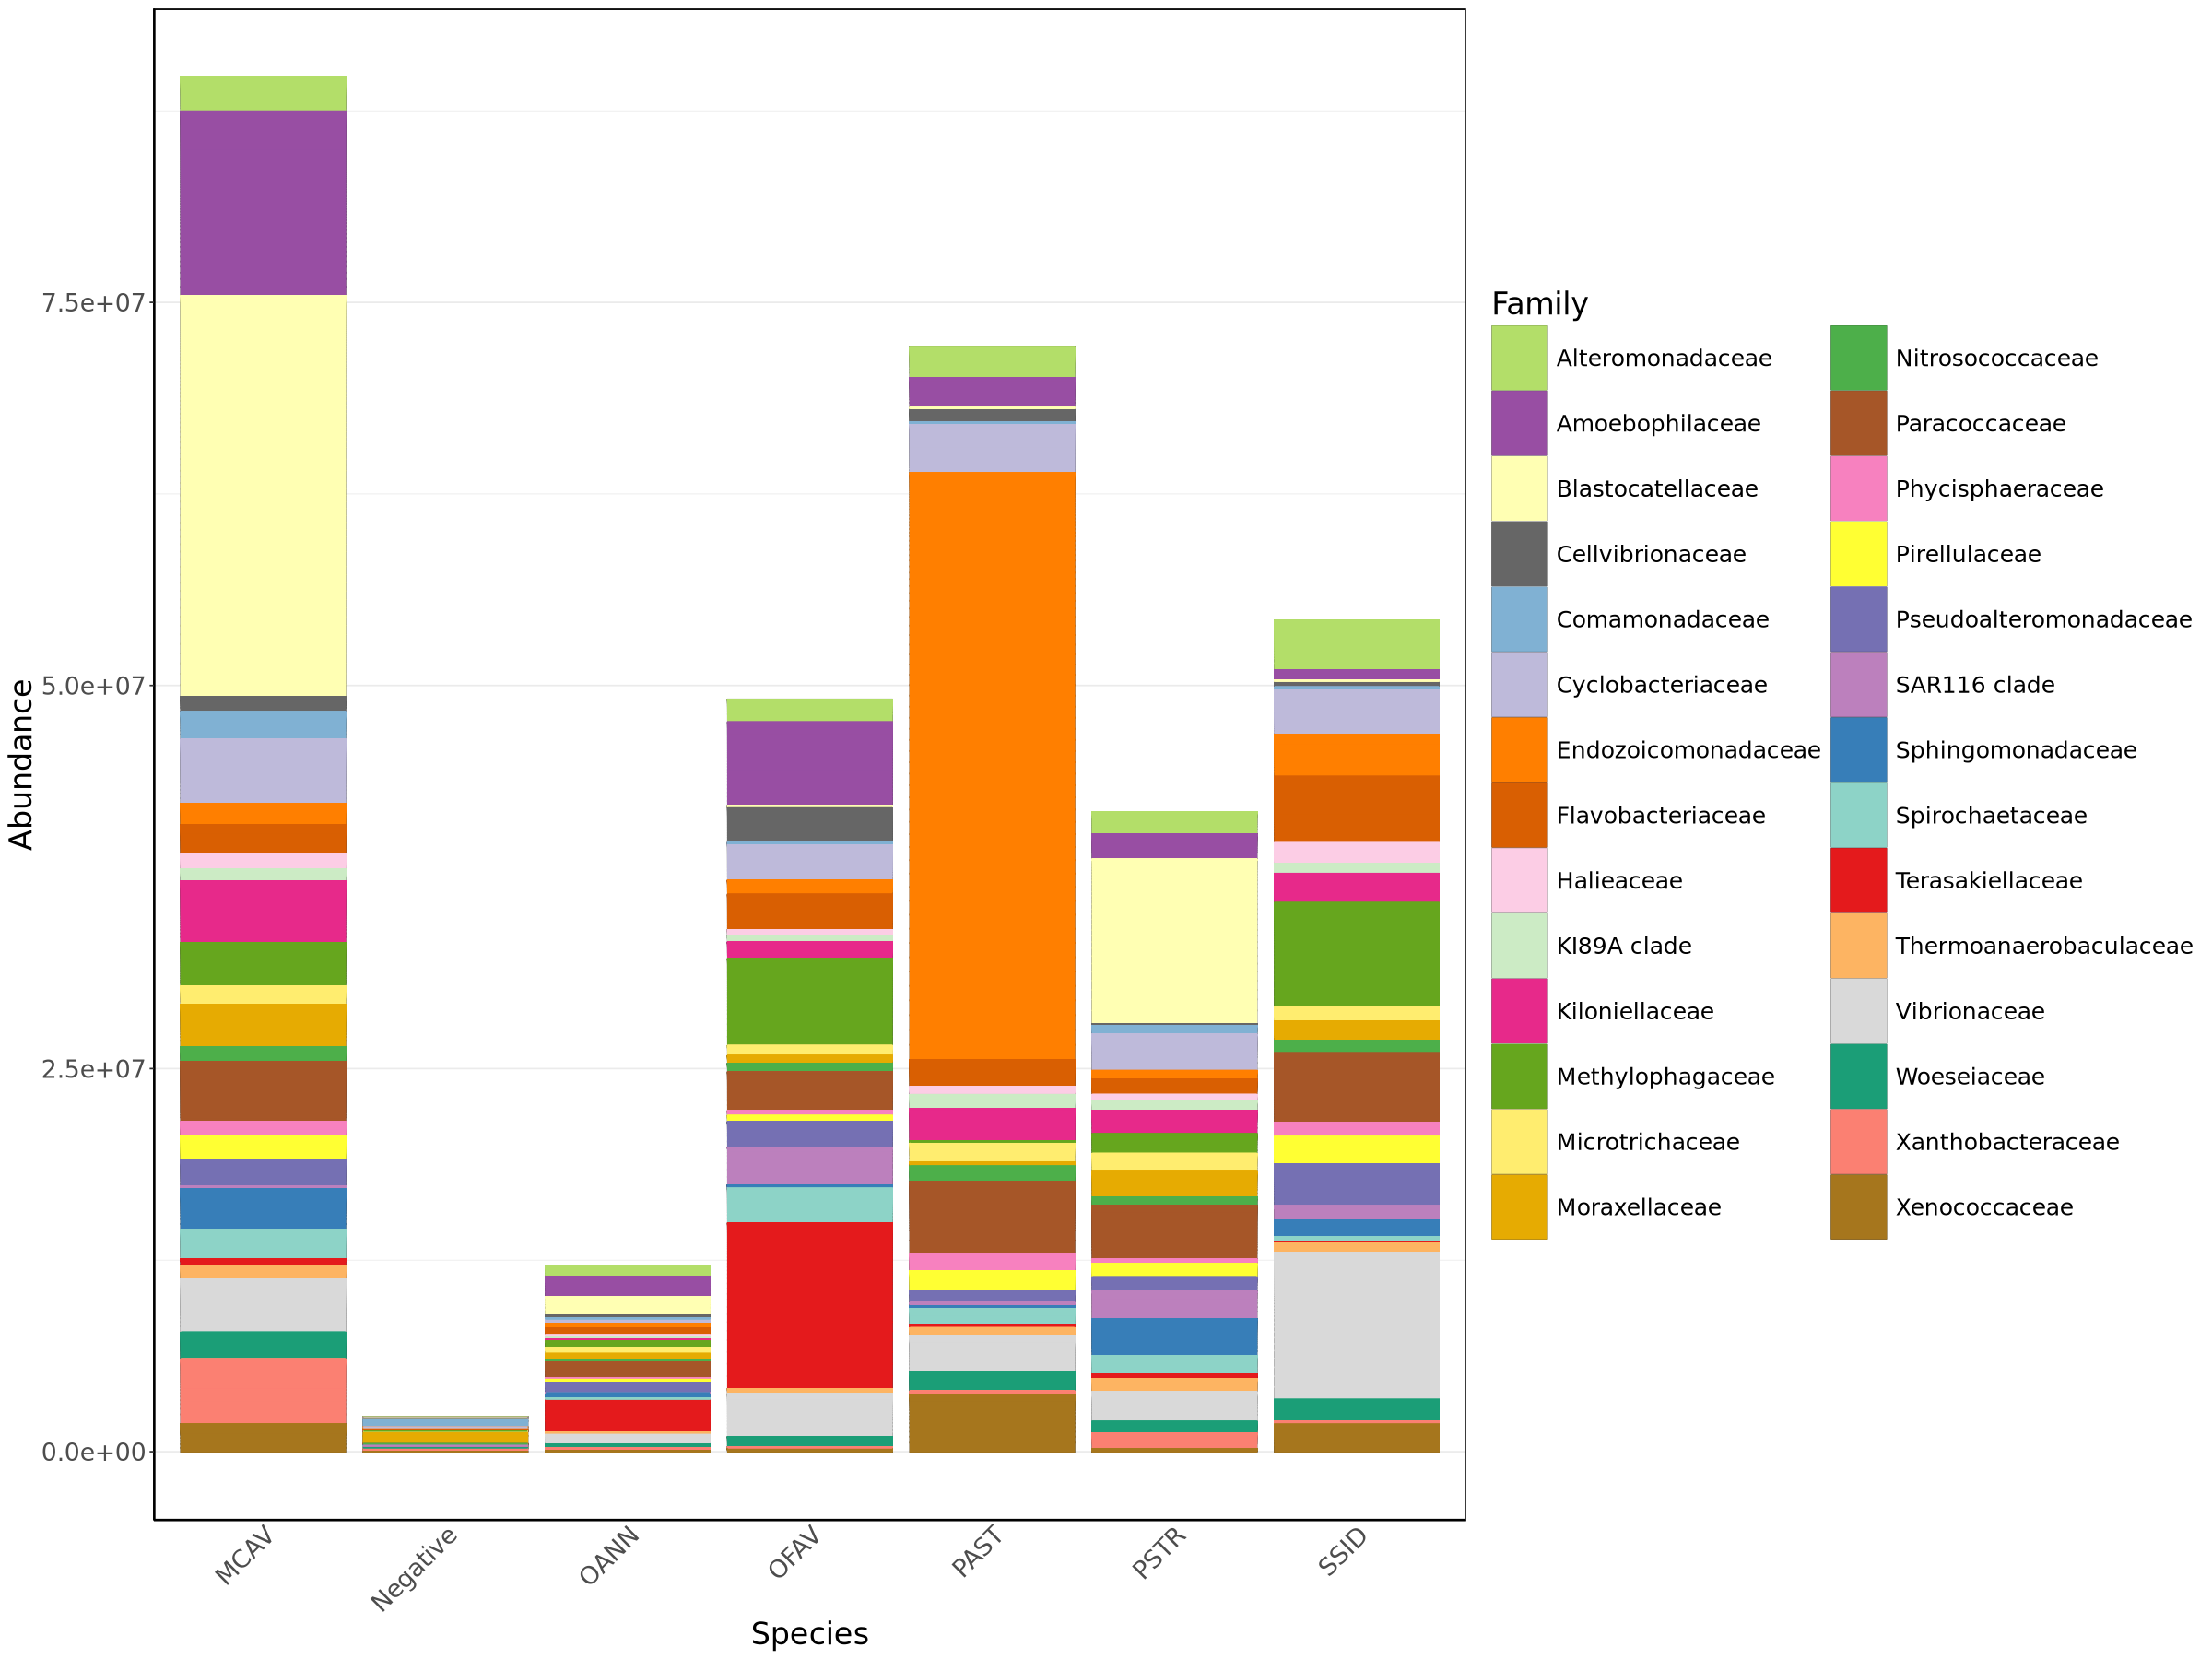

In [191]:
#plot
fam_28 <- plot_bar(ps_fam28, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = colors_28, drop = TRUE) +
  scale_color_manual(values = colors_28, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )+
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_28

# How are the microbiomes of individual coral colonies changing overtime?
- do they recruit fewer bacteria?
- do they shift to recruiting new bacteria?

### subset by cora host species to make plots easier to read

In [30]:

#new dataframes for each species 
ps_mcav <- subset_samples(ps_col, Species == "MCAV")
ps_pstr <- subset_samples(ps_col, Species == "PSTR")
ps_ofav <- subset_samples(ps_col, Species == "OFAV")
ps_ssid <- subset_samples(ps_col, Species == "SSID")
ps_oann <- subset_samples(ps_col, Species == "OANN")
ps_past <- subset_samples(ps_col, Species == "PAST") 

In [31]:
#should add up to 428 samples
nrow(sample_data(ps_mcav))
nrow(sample_data(ps_pstr))
nrow(sample_data(ps_ofav))
nrow(sample_data(ps_oann))
nrow(sample_data(ps_ssid))
nrow(sample_data(ps_past))

[1] 119

[1] 56

[1] 61

[1] 16

[1] 80

[1] 93

In [32]:
#how many colonies? 68
table(sample_data(ps_col)[,"colony"])

colony
  0_0  1_12  1_13  1_14  1_15  1_16  1_17  1_19   1_2  1_20  1_21  1_22  1_24 
    3    11     4     2     2     2     3     3     9     3     7     4    12 
 1_25   1_3   1_4   1_5   1_6   1_8  2_30  2_52  2_55  2_56  2_57  2_59  2_60 
    9    11     2     2     3     3     2     2    11     3    11     2    11 
 2_63  2_68  2_69  2_70  2_72  2_73  2_76  2_79  2_80  2_99  3_10  3_14  3_15 
   11    11    11     2    11    11    10    10     3     8     9    10     3 
 3_17  3_18  3_19   3_2  3_20  3_21  3_22  3_24  3_28   3_3  3_33  3_34  3_38 
    2     3     2    11    11    11     2     3     3     2    11    11    10 
 3_39   3_5   3_6  3_66  3_70 4_100  4_28  4_30  4_76  4_78  4_79  4_98 
   10    11     6     8     9     2     8     9     9     9     9     9 

## family plots for each species 
- facetted by colony

# How do the microbiomes of individual colonies change with exposure to stressors like heat and disease?
- P. asteroides seem to lose their endozoic communities after bleaching, and gain them back after recovery
- MCAV and PSTR (that did not contract SCTLD) seem to develop larger Blastocatallacae commuinities after disease outbreak

### past

<Guides[1] ggproto object>

colour : <GuideLegend>

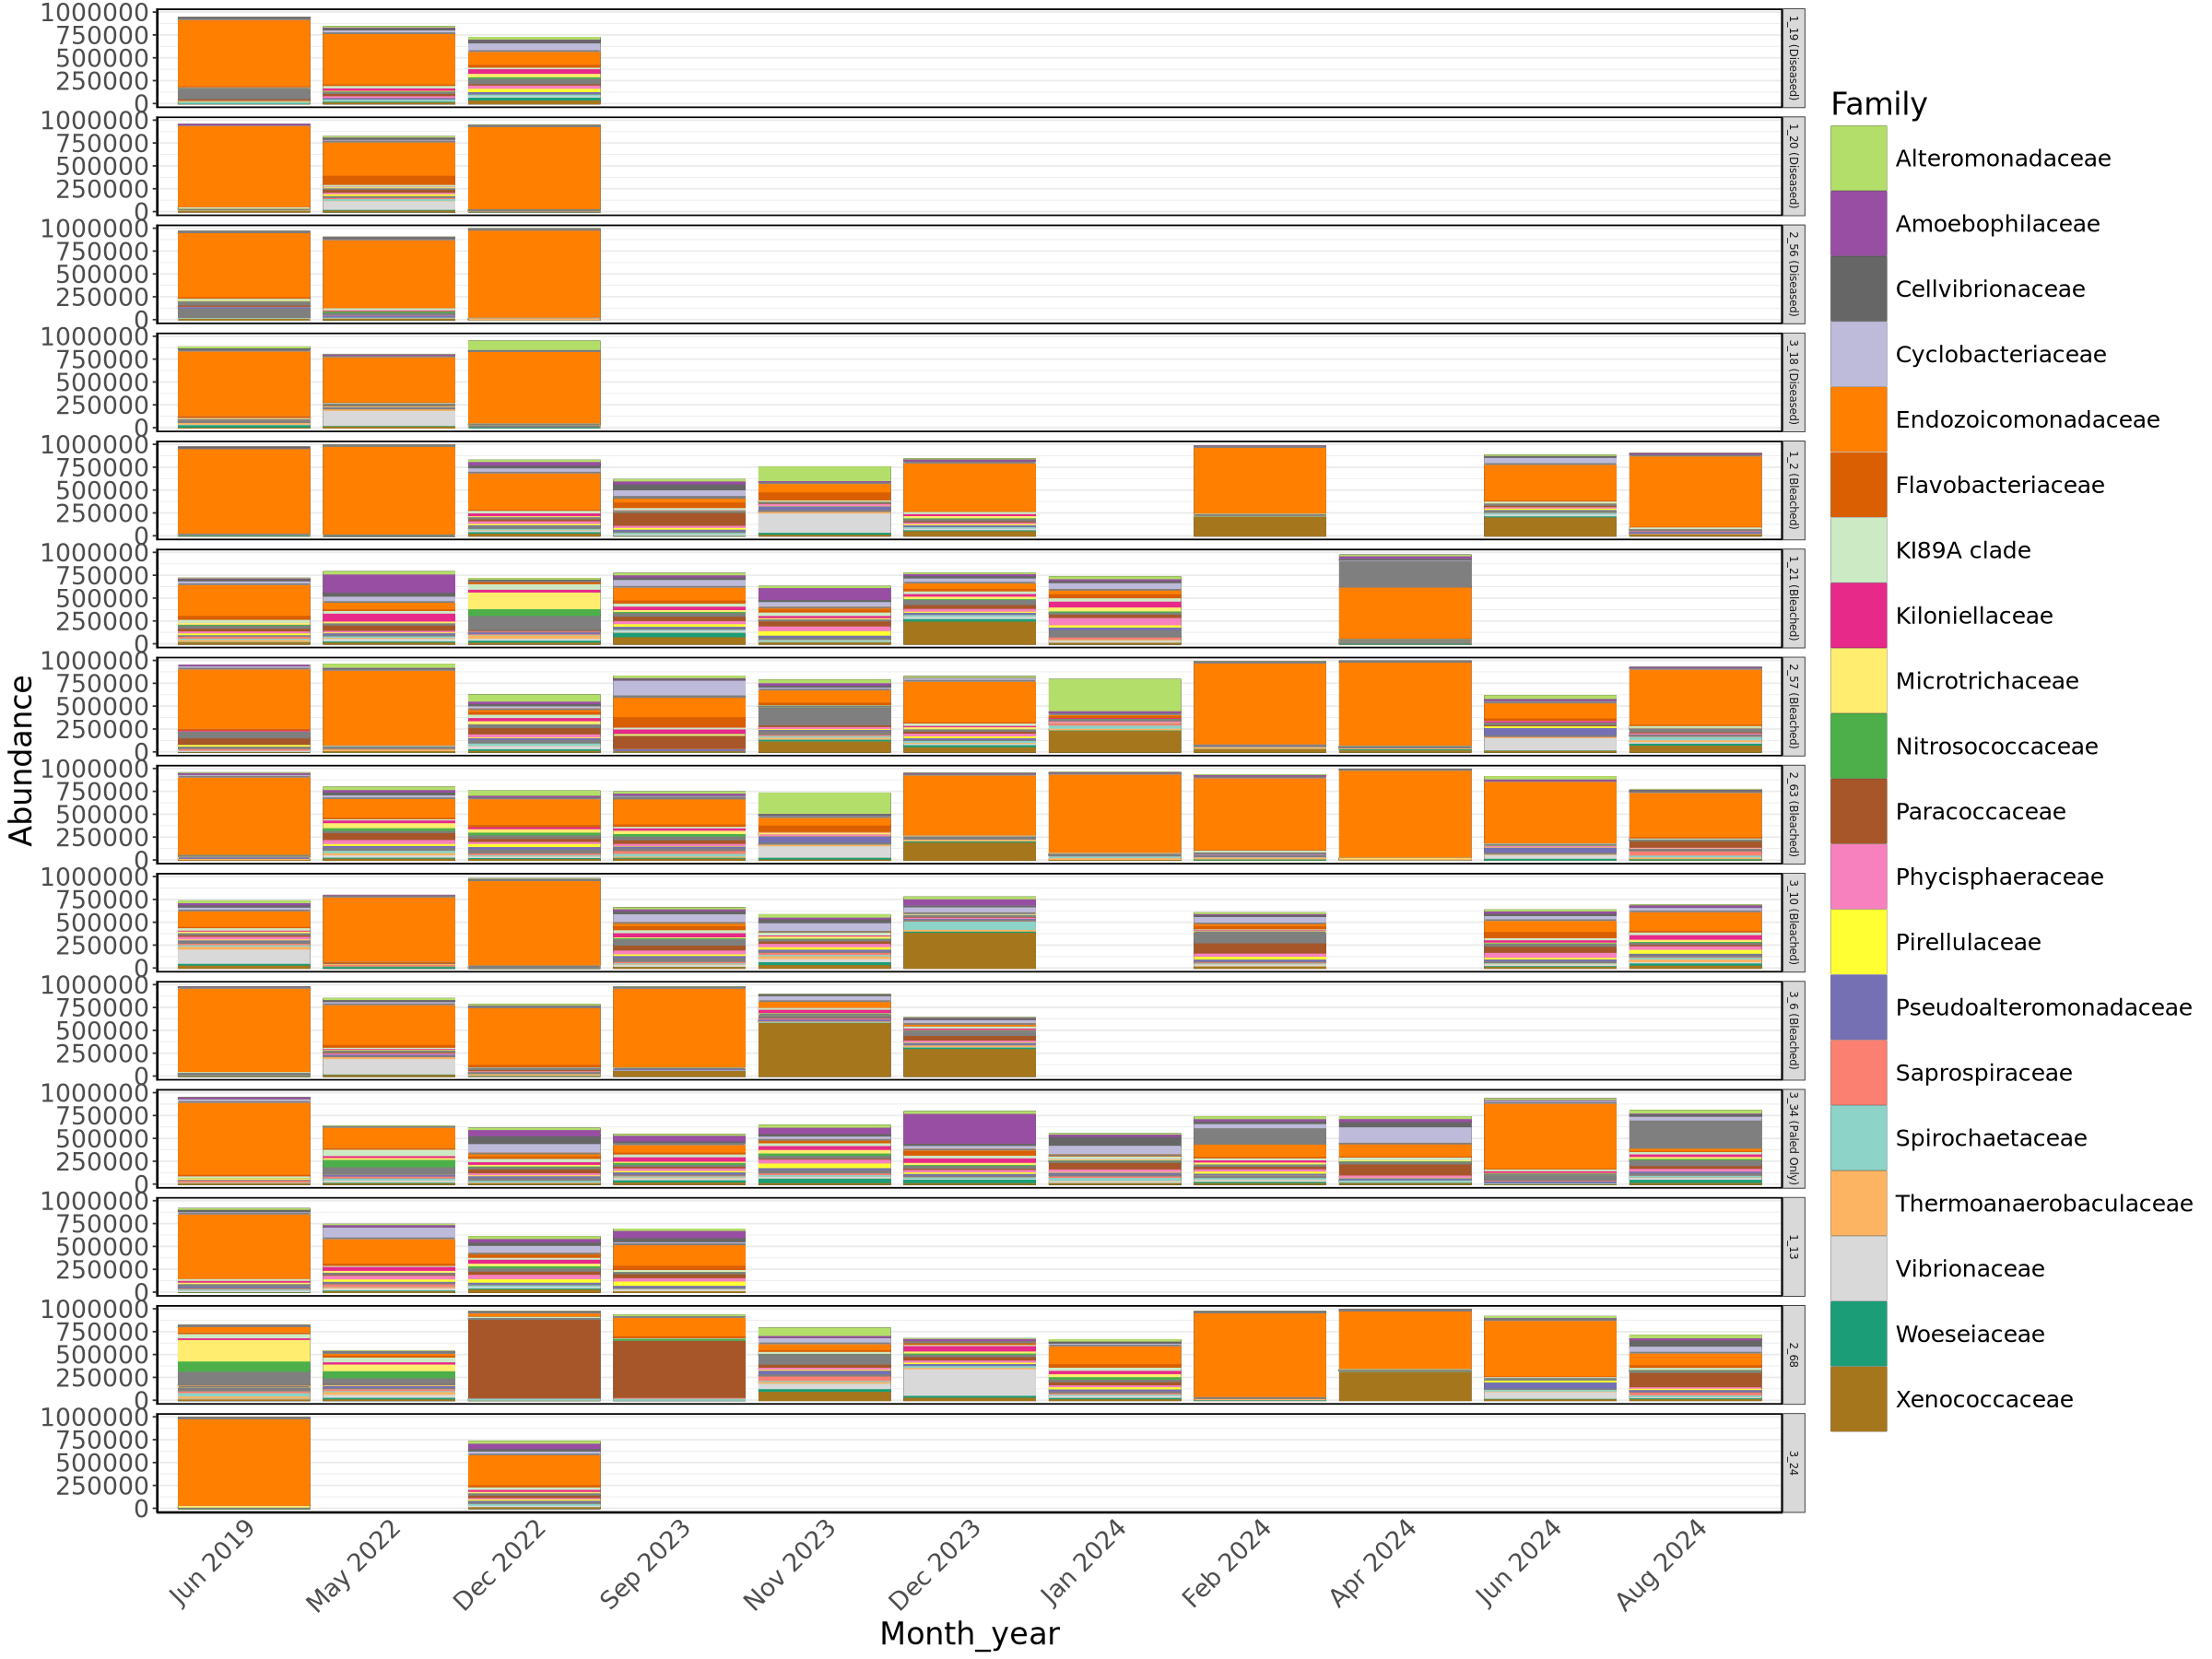

In [36]:
ps_past=tax_glom(ps_past, taxrank= "Family")

top25_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:25] 
top25_past <- prune_taxa(top25_past, ps_past) 

#plot
past <- plot_bar(top25_past, x="Month_year", fill = "Family") +
  facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20), 
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

- **what disease did 1_19, 1_20, 2_56, and 3_18 have?**
- *these are non-immune samples, sankey plot can be found here* https://github.com/leahharper/SCTLD_demographics/blob/main/Figures/current/Fig%203.png
- 3_18 has since been sampled as healthy https://drive.google.com/drive/folders/1nSGHY2wvVjFv9pwx14g6OERhEeFM2LOz
- 2_56 was also H, Dis, H and now dead
- 1_19 and 1_20 conditions H, Disease, H, CLP, Dead

### figure notes
- The figure above shows us that P. asteroides microbiomes are changing temporarily after bleaching. For example: in Sep 2023 and before, most colonies had high relative abundances of endozoicomonas, whereas for bleached samples the endozoicomonas populations are decreased.
- We also see patterns of endozoicomonas recovery in P. asteroides colonies that recovered from bleaching.
- only one colony (3_34) exclusively paled and this one seemed to hold off on reintroducing endozoic and rediversified its bacterial community in Aug2024 (**potentially in preparation for the next heatwave?**)

### pstr

<Guides[1] ggproto object>

colour : <GuideLegend>

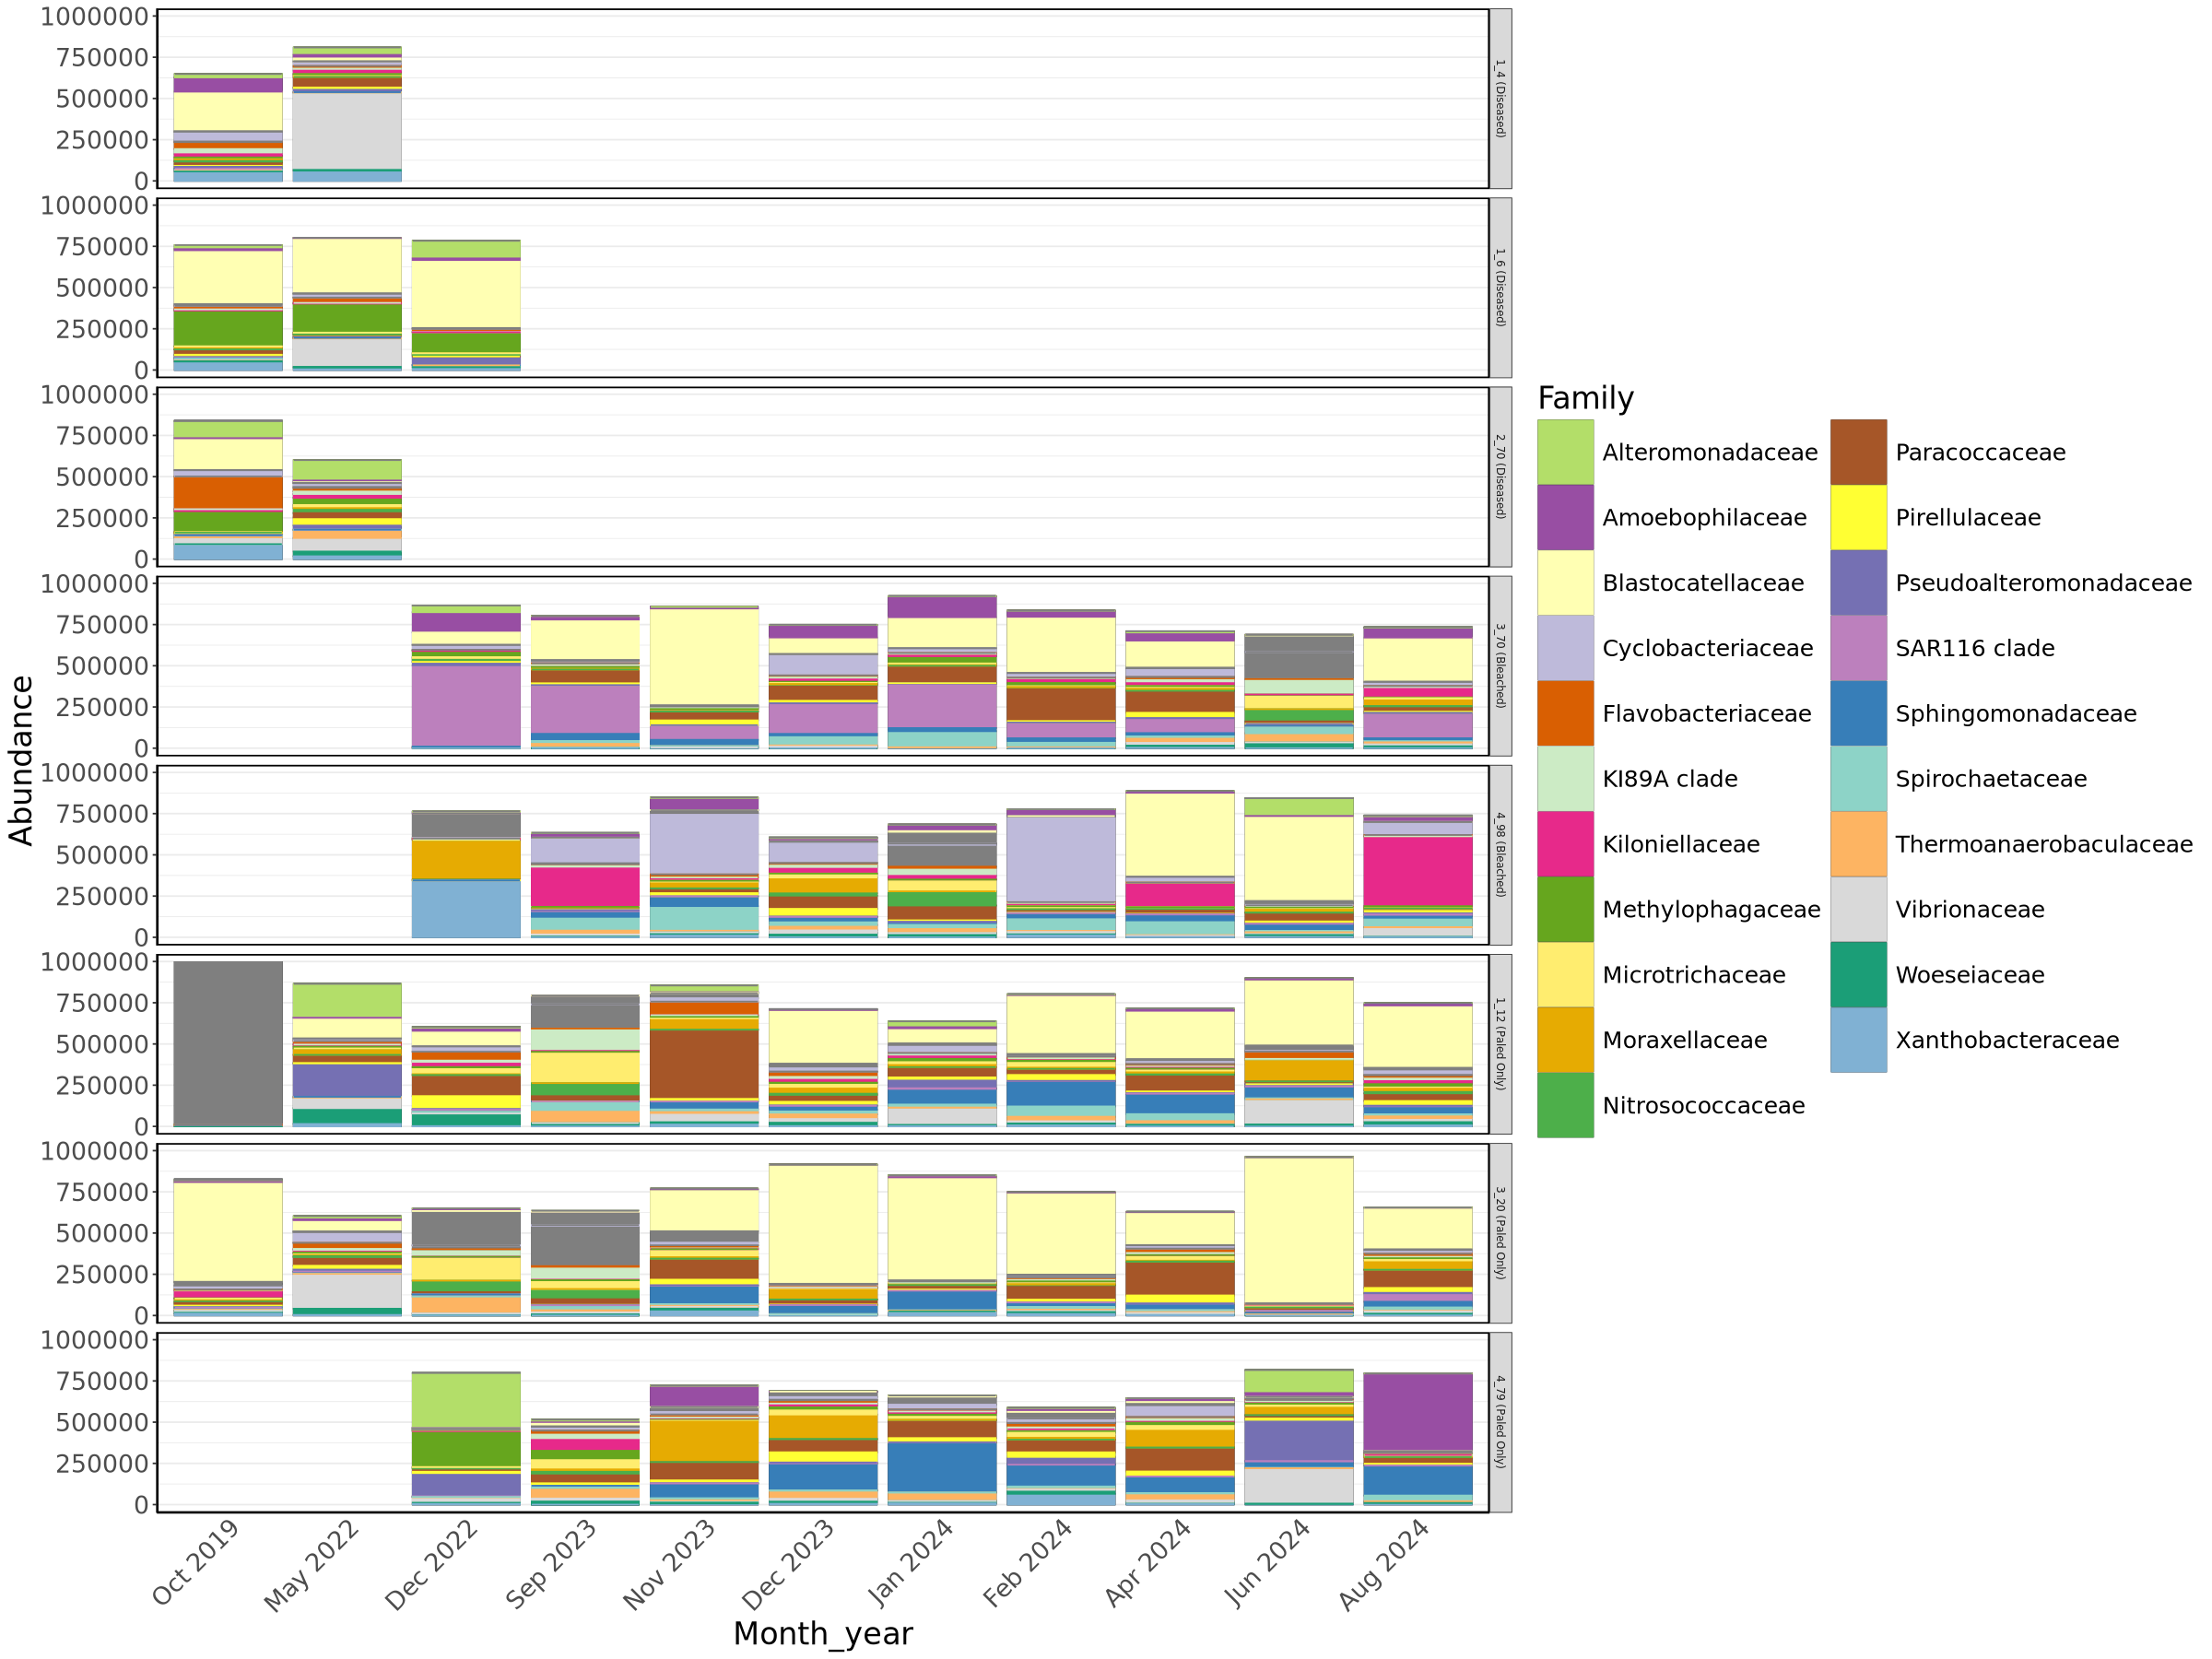

In [37]:
#reduce to top 50
fam_pstr=tax_glom(ps_pstr, taxrank= "Family")

top25_pstr <- names(sort(taxa_sums(fam_pstr), decreasing=TRUE))[1:25] 
fam25_pstr <- prune_taxa(top25_pstr, fam_pstr) 

#plot
fam_pstr <- plot_bar(fam25_pstr, x="Month_year", fill="Family") +
   facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20),
                 strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_pstr

corrections made to this plot
- i had accidentally excluded Oct 2019 from the plots, so that date was showing up as NA
- colonies that were sampled as diseased_margin and diseased_tissue at one time point were being counted toward a colony sampled twice, but only showing up in the plot as one time point. to fix this I have temporaily removed Diseased_Margin samples from the original ps object **refer to line 42**

### figure notes 
- We may be seeing a reduction of microbiome community diversity in PSTR's after disease and bleaching
    - increase in blastocatellacea after Nov 2023
- absolutely NO endozoicomonas in PSTR
- there are no completely healthy PSTR's (all experienced some disease or color loss)
- after grouping the colonies into diseased, bleached, only_paled and healthy we can see that Alteromonadacae and Methylophagacae are primarily present in 2019 and 2022 (even in 4_79 which was never diseased and lost Altero and Methylo

### questions about this figure
- we see increased 16S diversity in Sept 2023, what month did our PSTR's bleach?
- Colony_data:
-  5 PSTR CLP in 092023
-  3 CLP, 2 CLB in 112023

### mcav

<Guides[1] ggproto object>

colour : <GuideLegend>

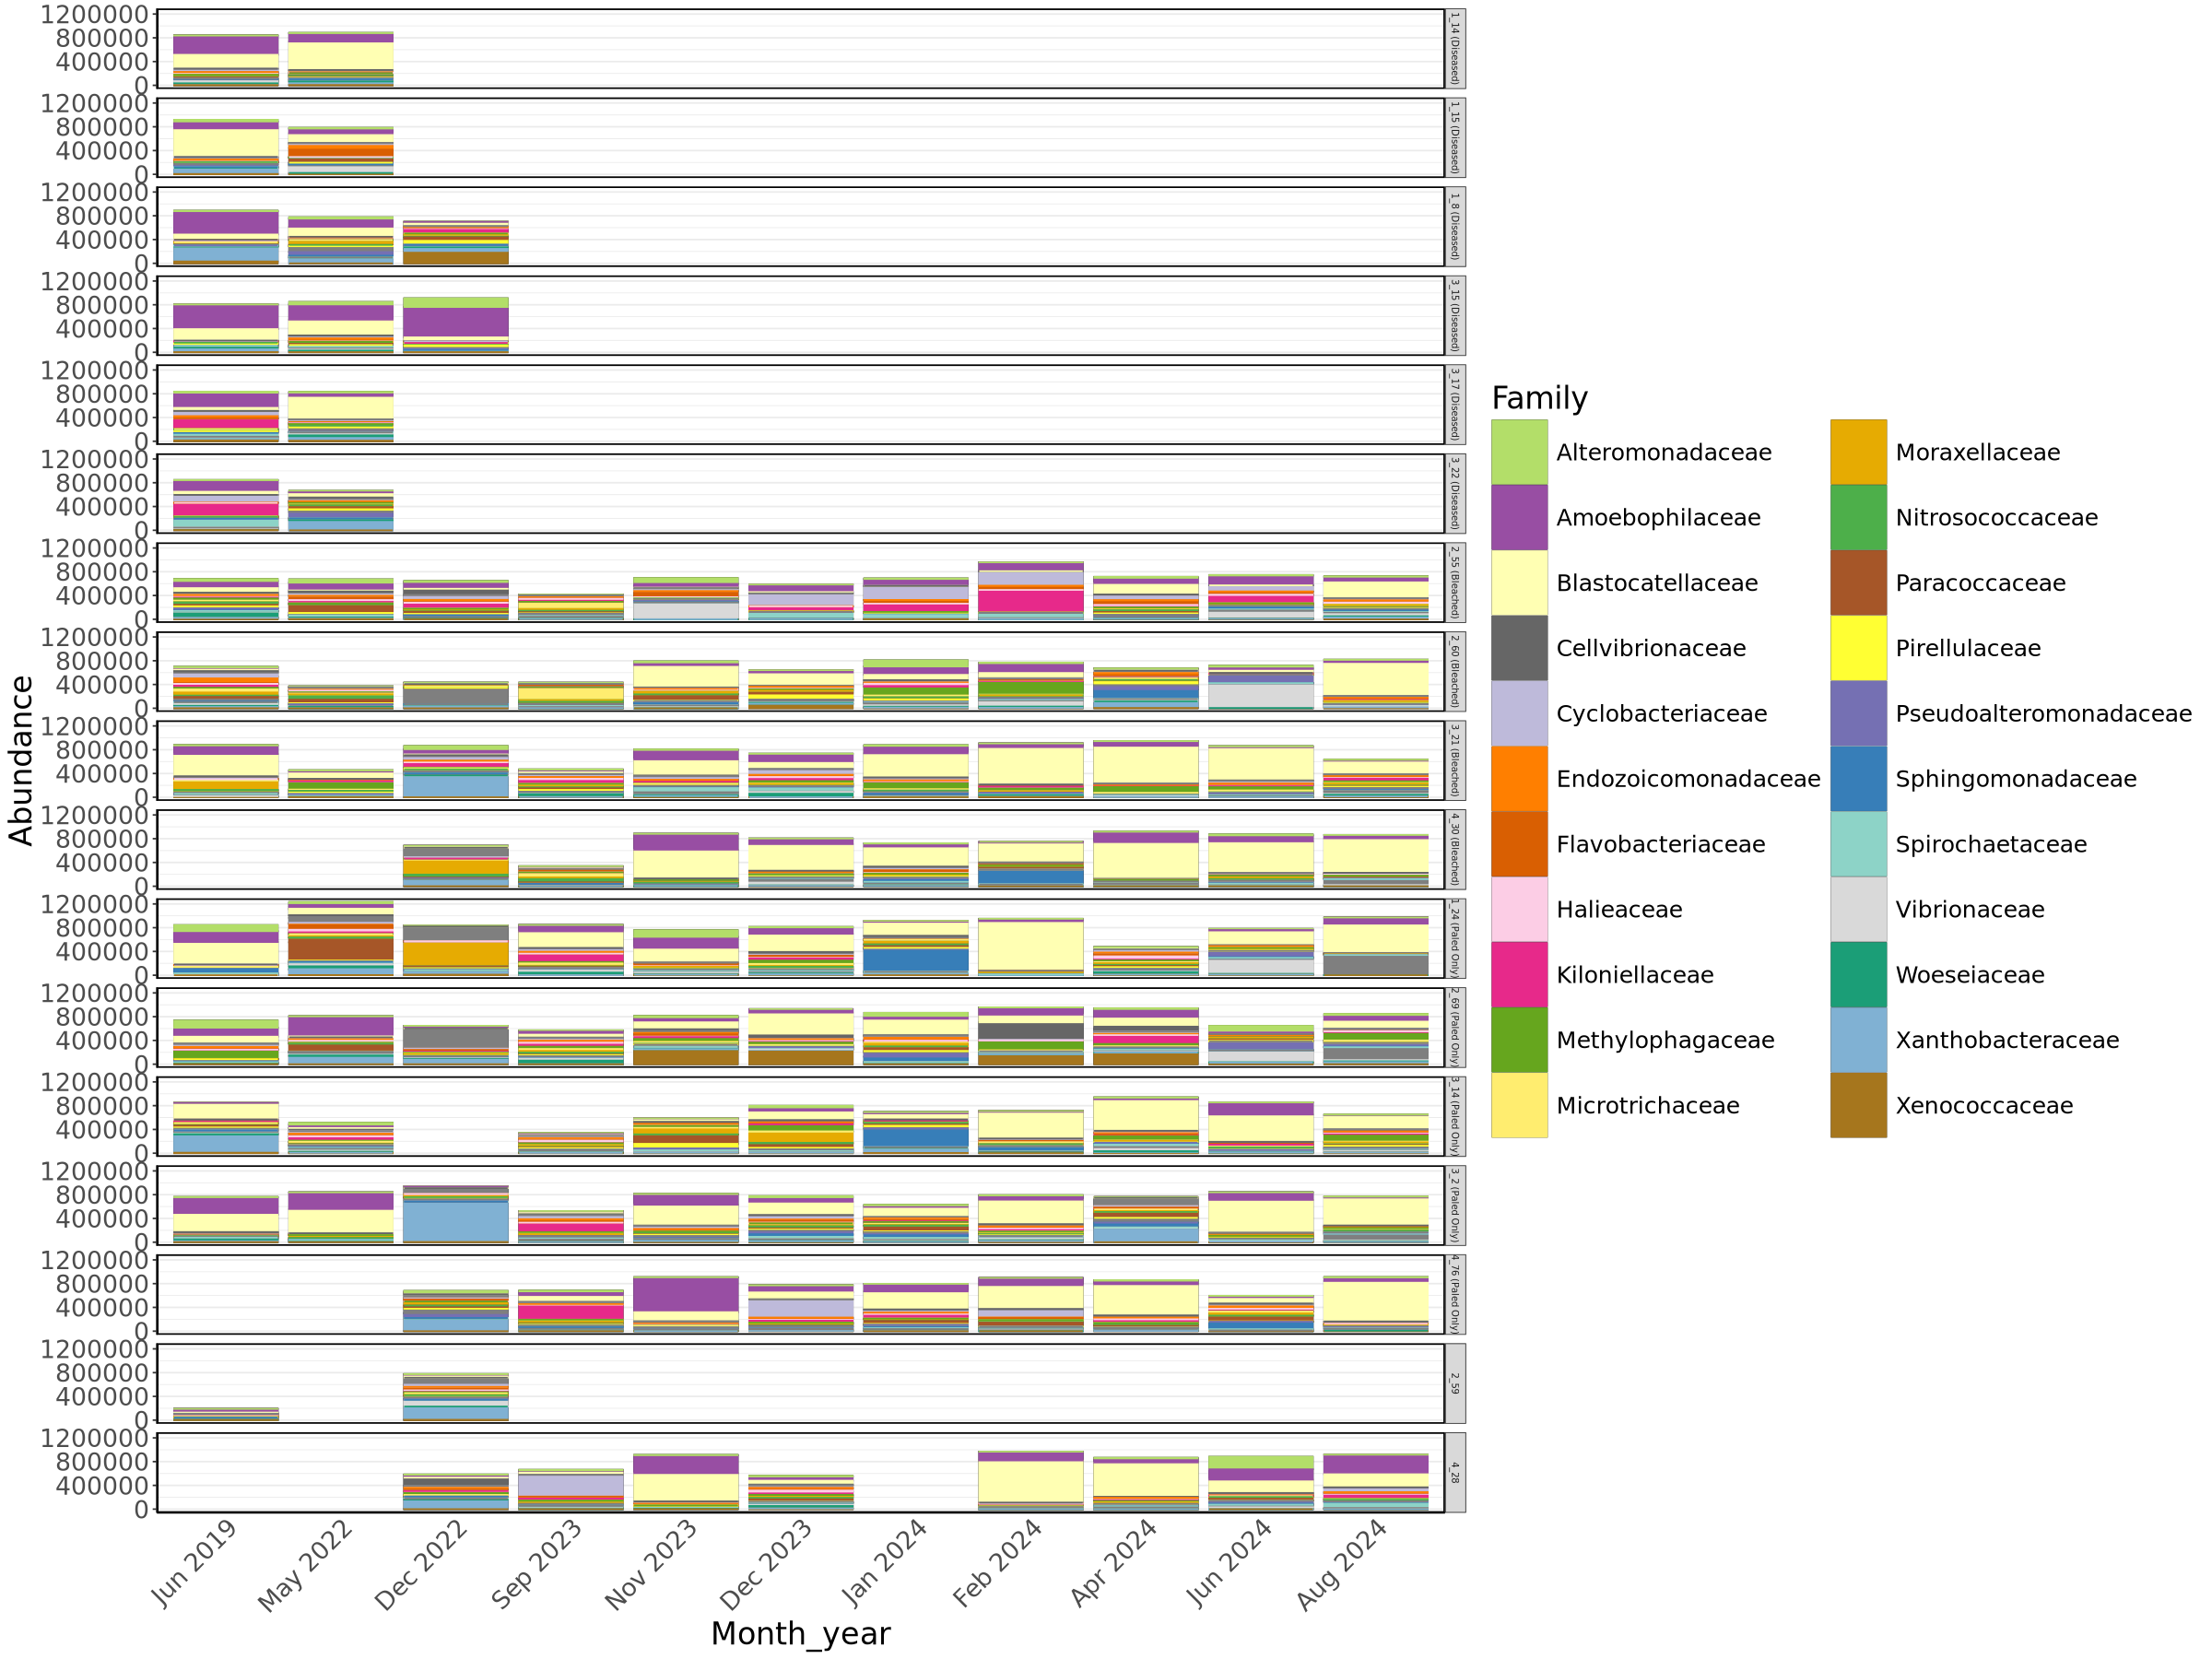

In [39]:
#reduce to top 50
fam_mcav=tax_glom(ps_mcav, taxrank= "Family")

top25_mcav <- names(sort(taxa_sums(fam_mcav), decreasing=TRUE))[1:25] 
top25_mcav <- prune_taxa(top25_mcav, fam_mcav) 

#plot
fam_mcav <- plot_bar(top25_mcav, x="Month_year", fill="Family") +
   facet_wrap(colony_labeled ~., strip.position = "right", ncol = 1) +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
   text = element_text(size = 20),
         strip.text = element_text(size = 6) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam_mcav

corrections made to this plot
- MCAV colony 3_2 was listed as "Diseased_Other" in conditions so I changed the code to represent all Conditions="Dieased" should be counted as SCTLD **refer to line 55**

### figure notes
- MCAV colonies grouped by disease, bleached, only_paled, healthy
- Look at the changes in alpha diversity over time because it seems that MCAV microbiomes were more diverse before disease and bleaching
    - similar to PSTR, increase in blastocatallacae after bleaching

## look at species health status before removal of Diseased_Margin **line 42**

### past health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

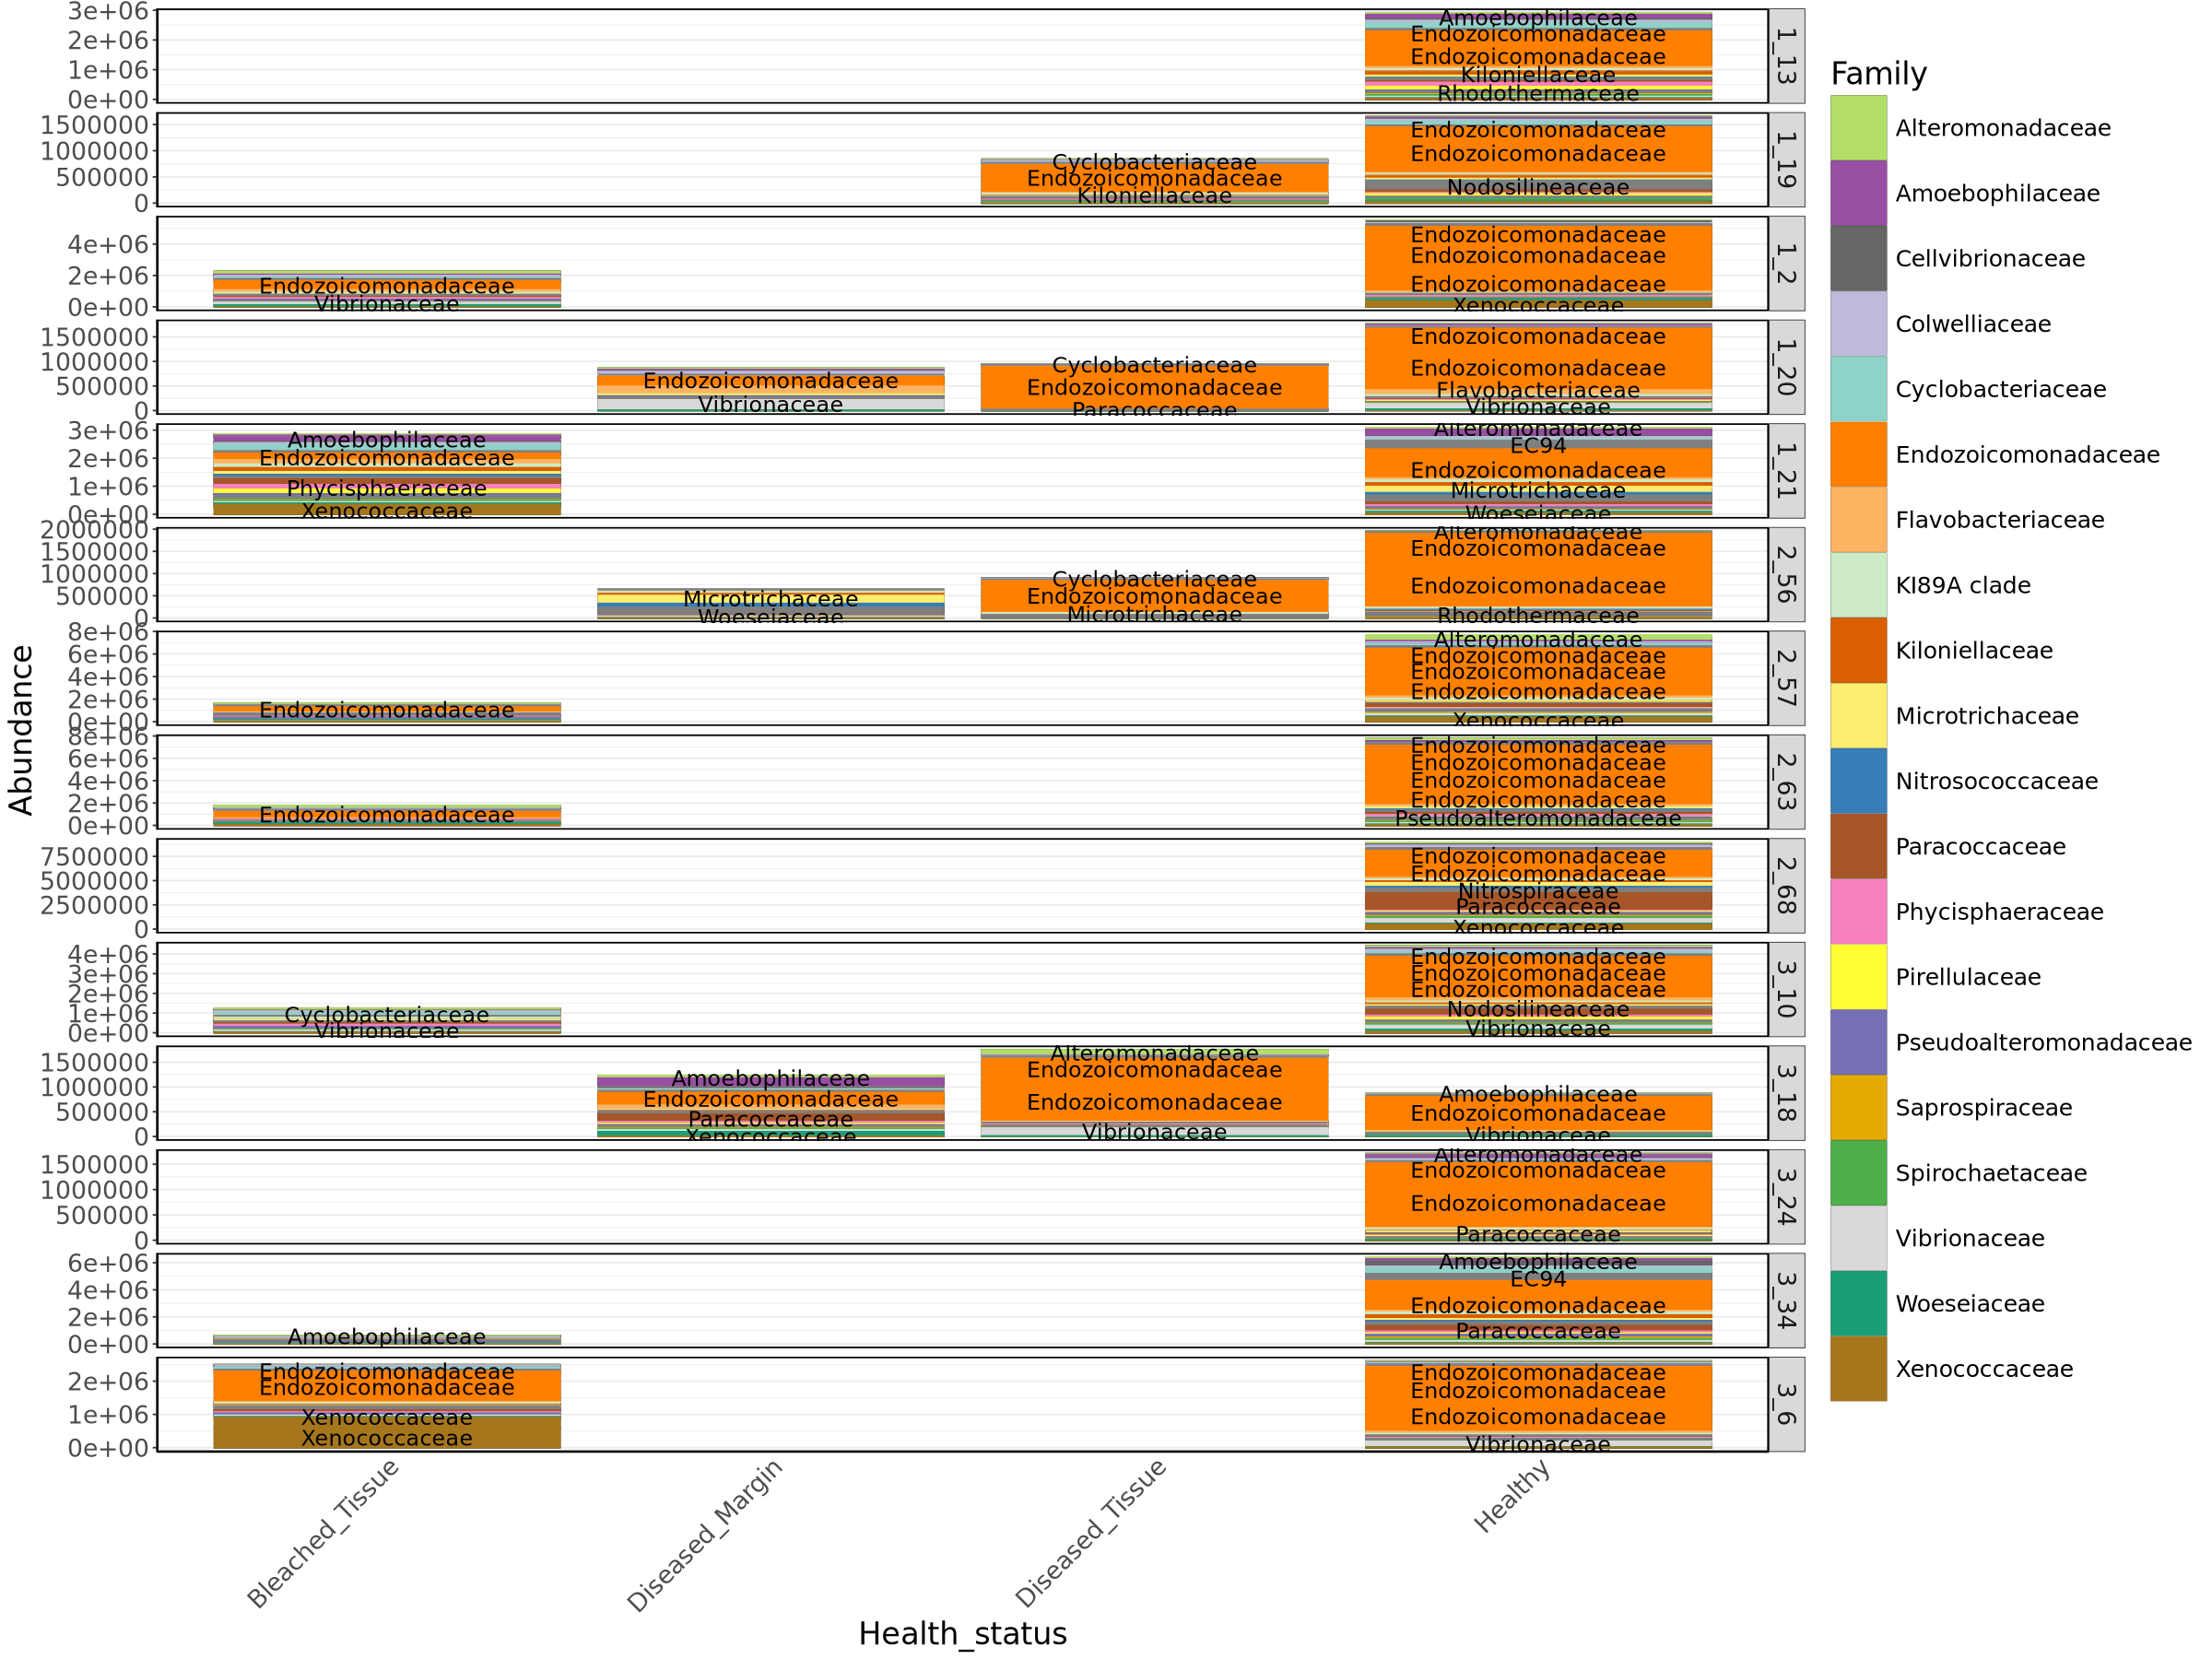

In [213]:
#plot
health_past <- plot_bar(top25_past, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_past

### mcavs health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

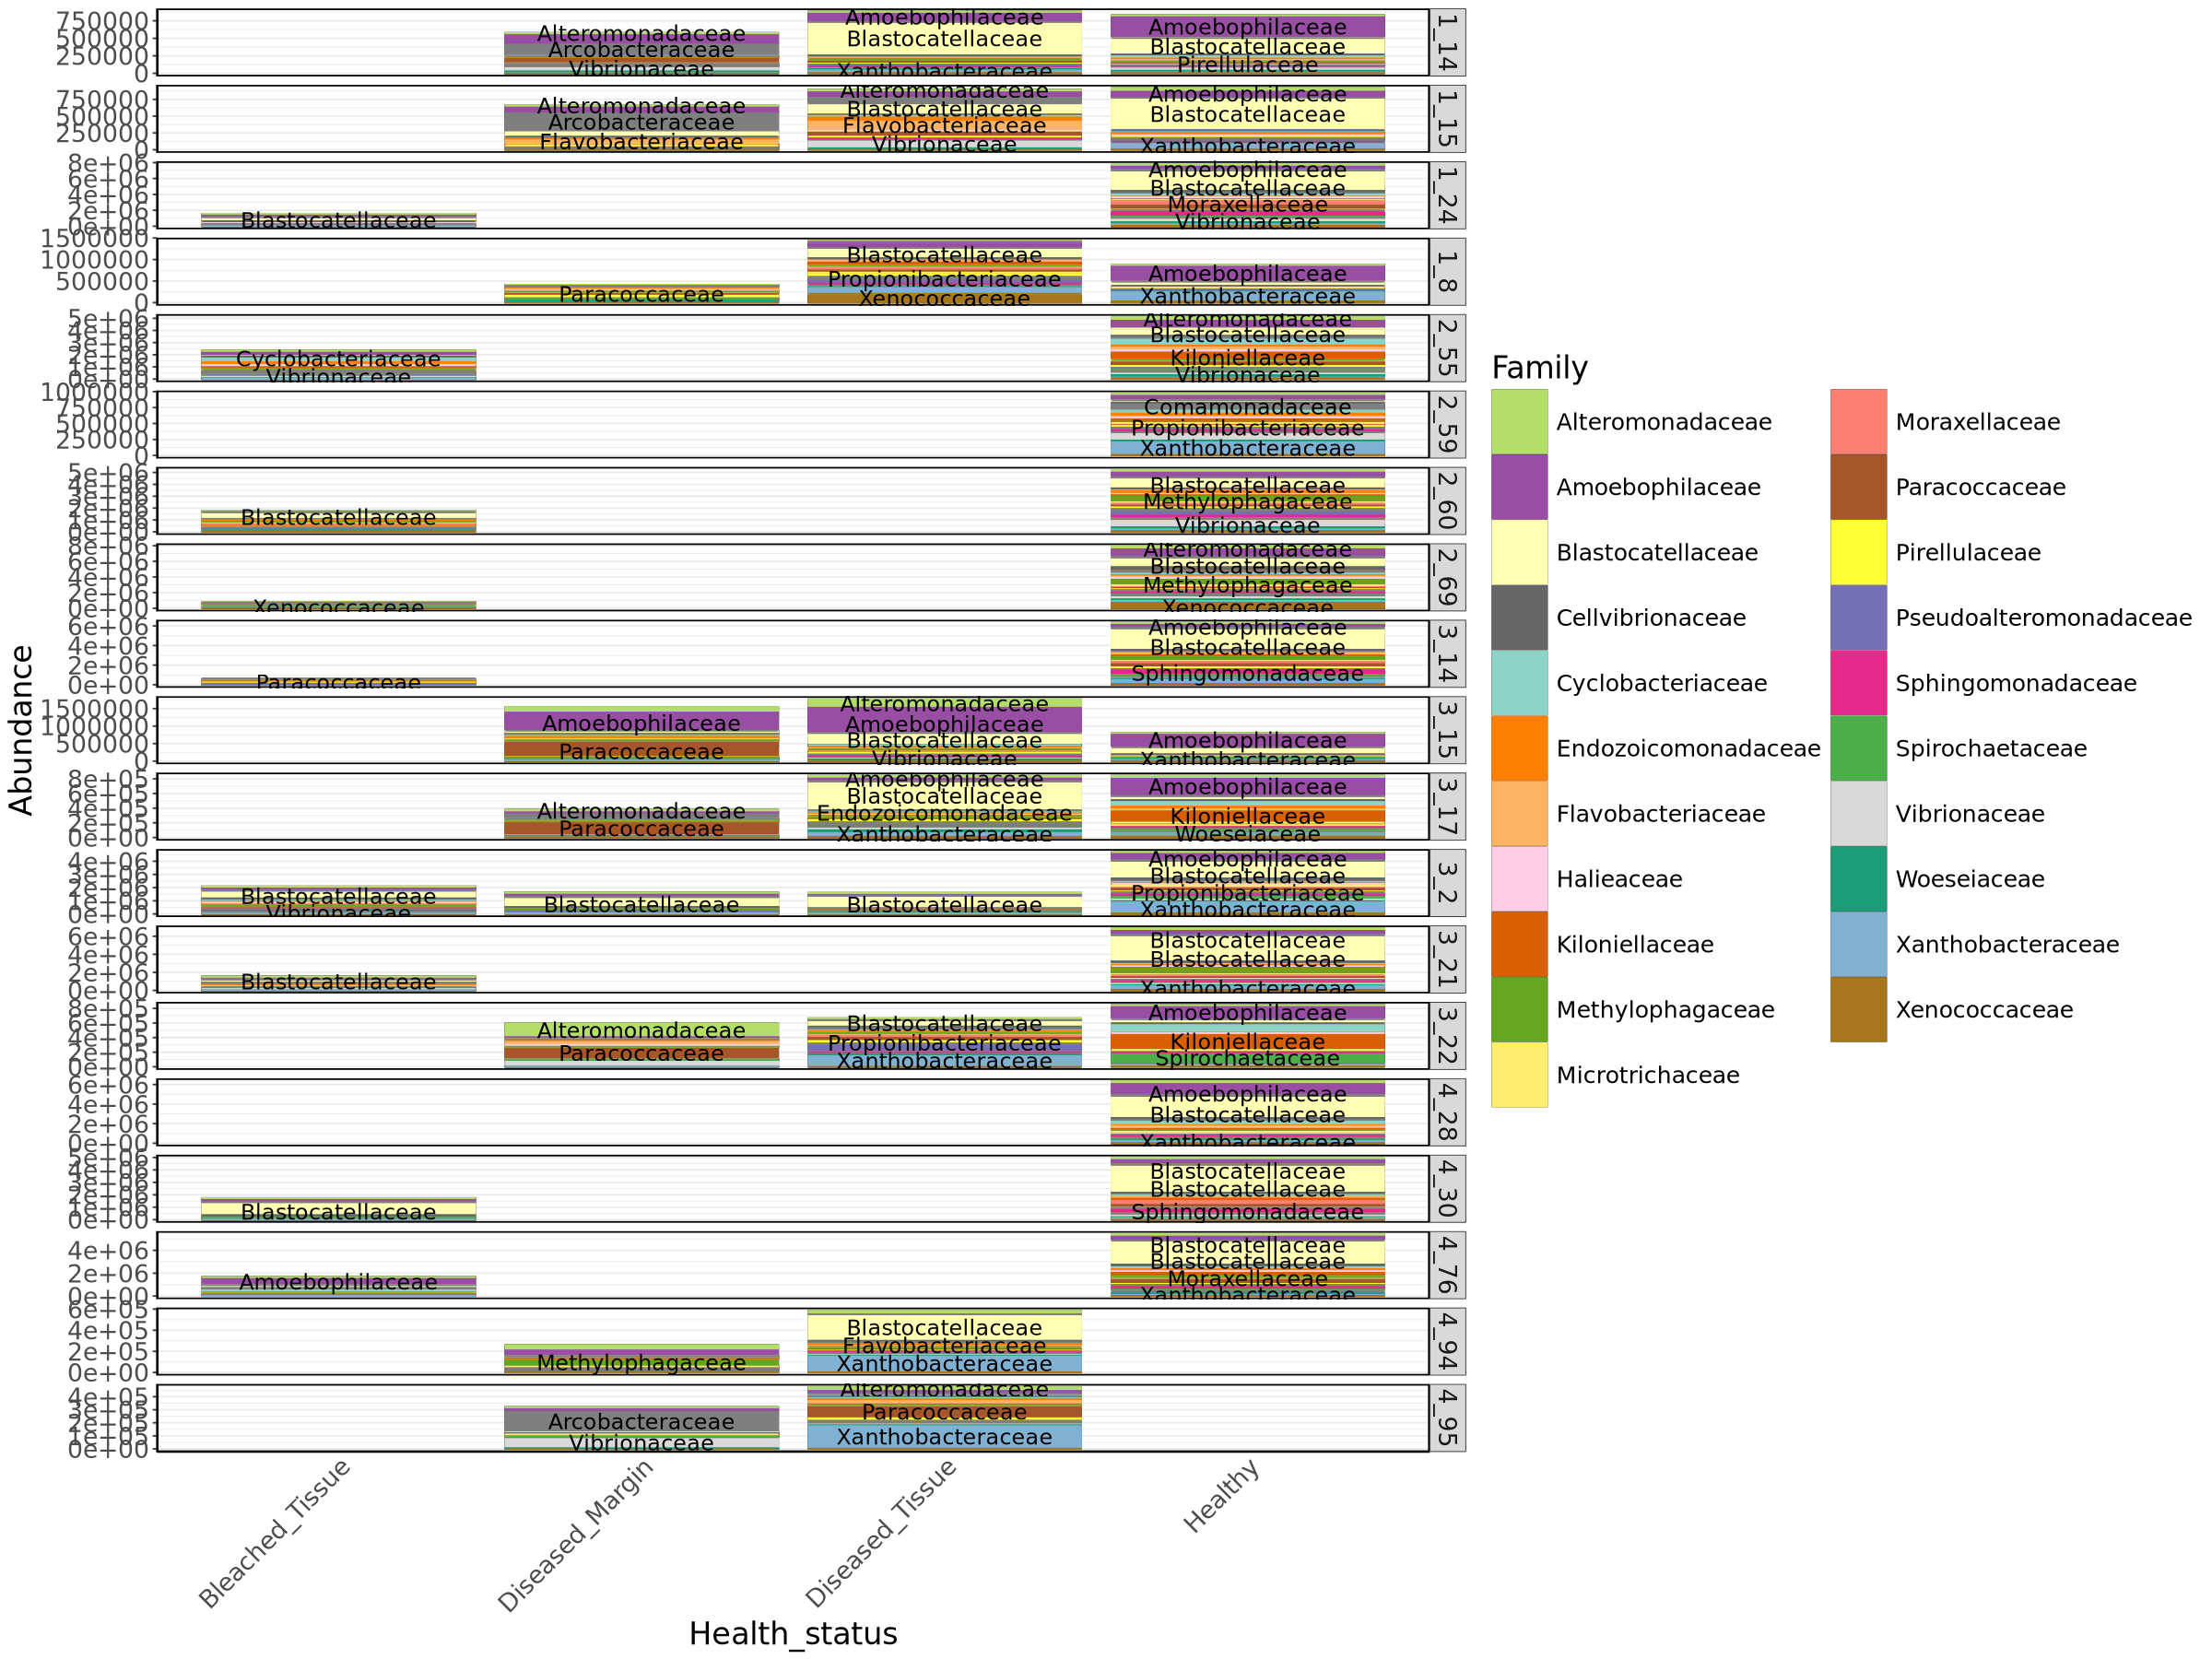

In [215]:

#plot
health_mcav <- plot_bar(top25_mcav, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_mcav

### pstr health status

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

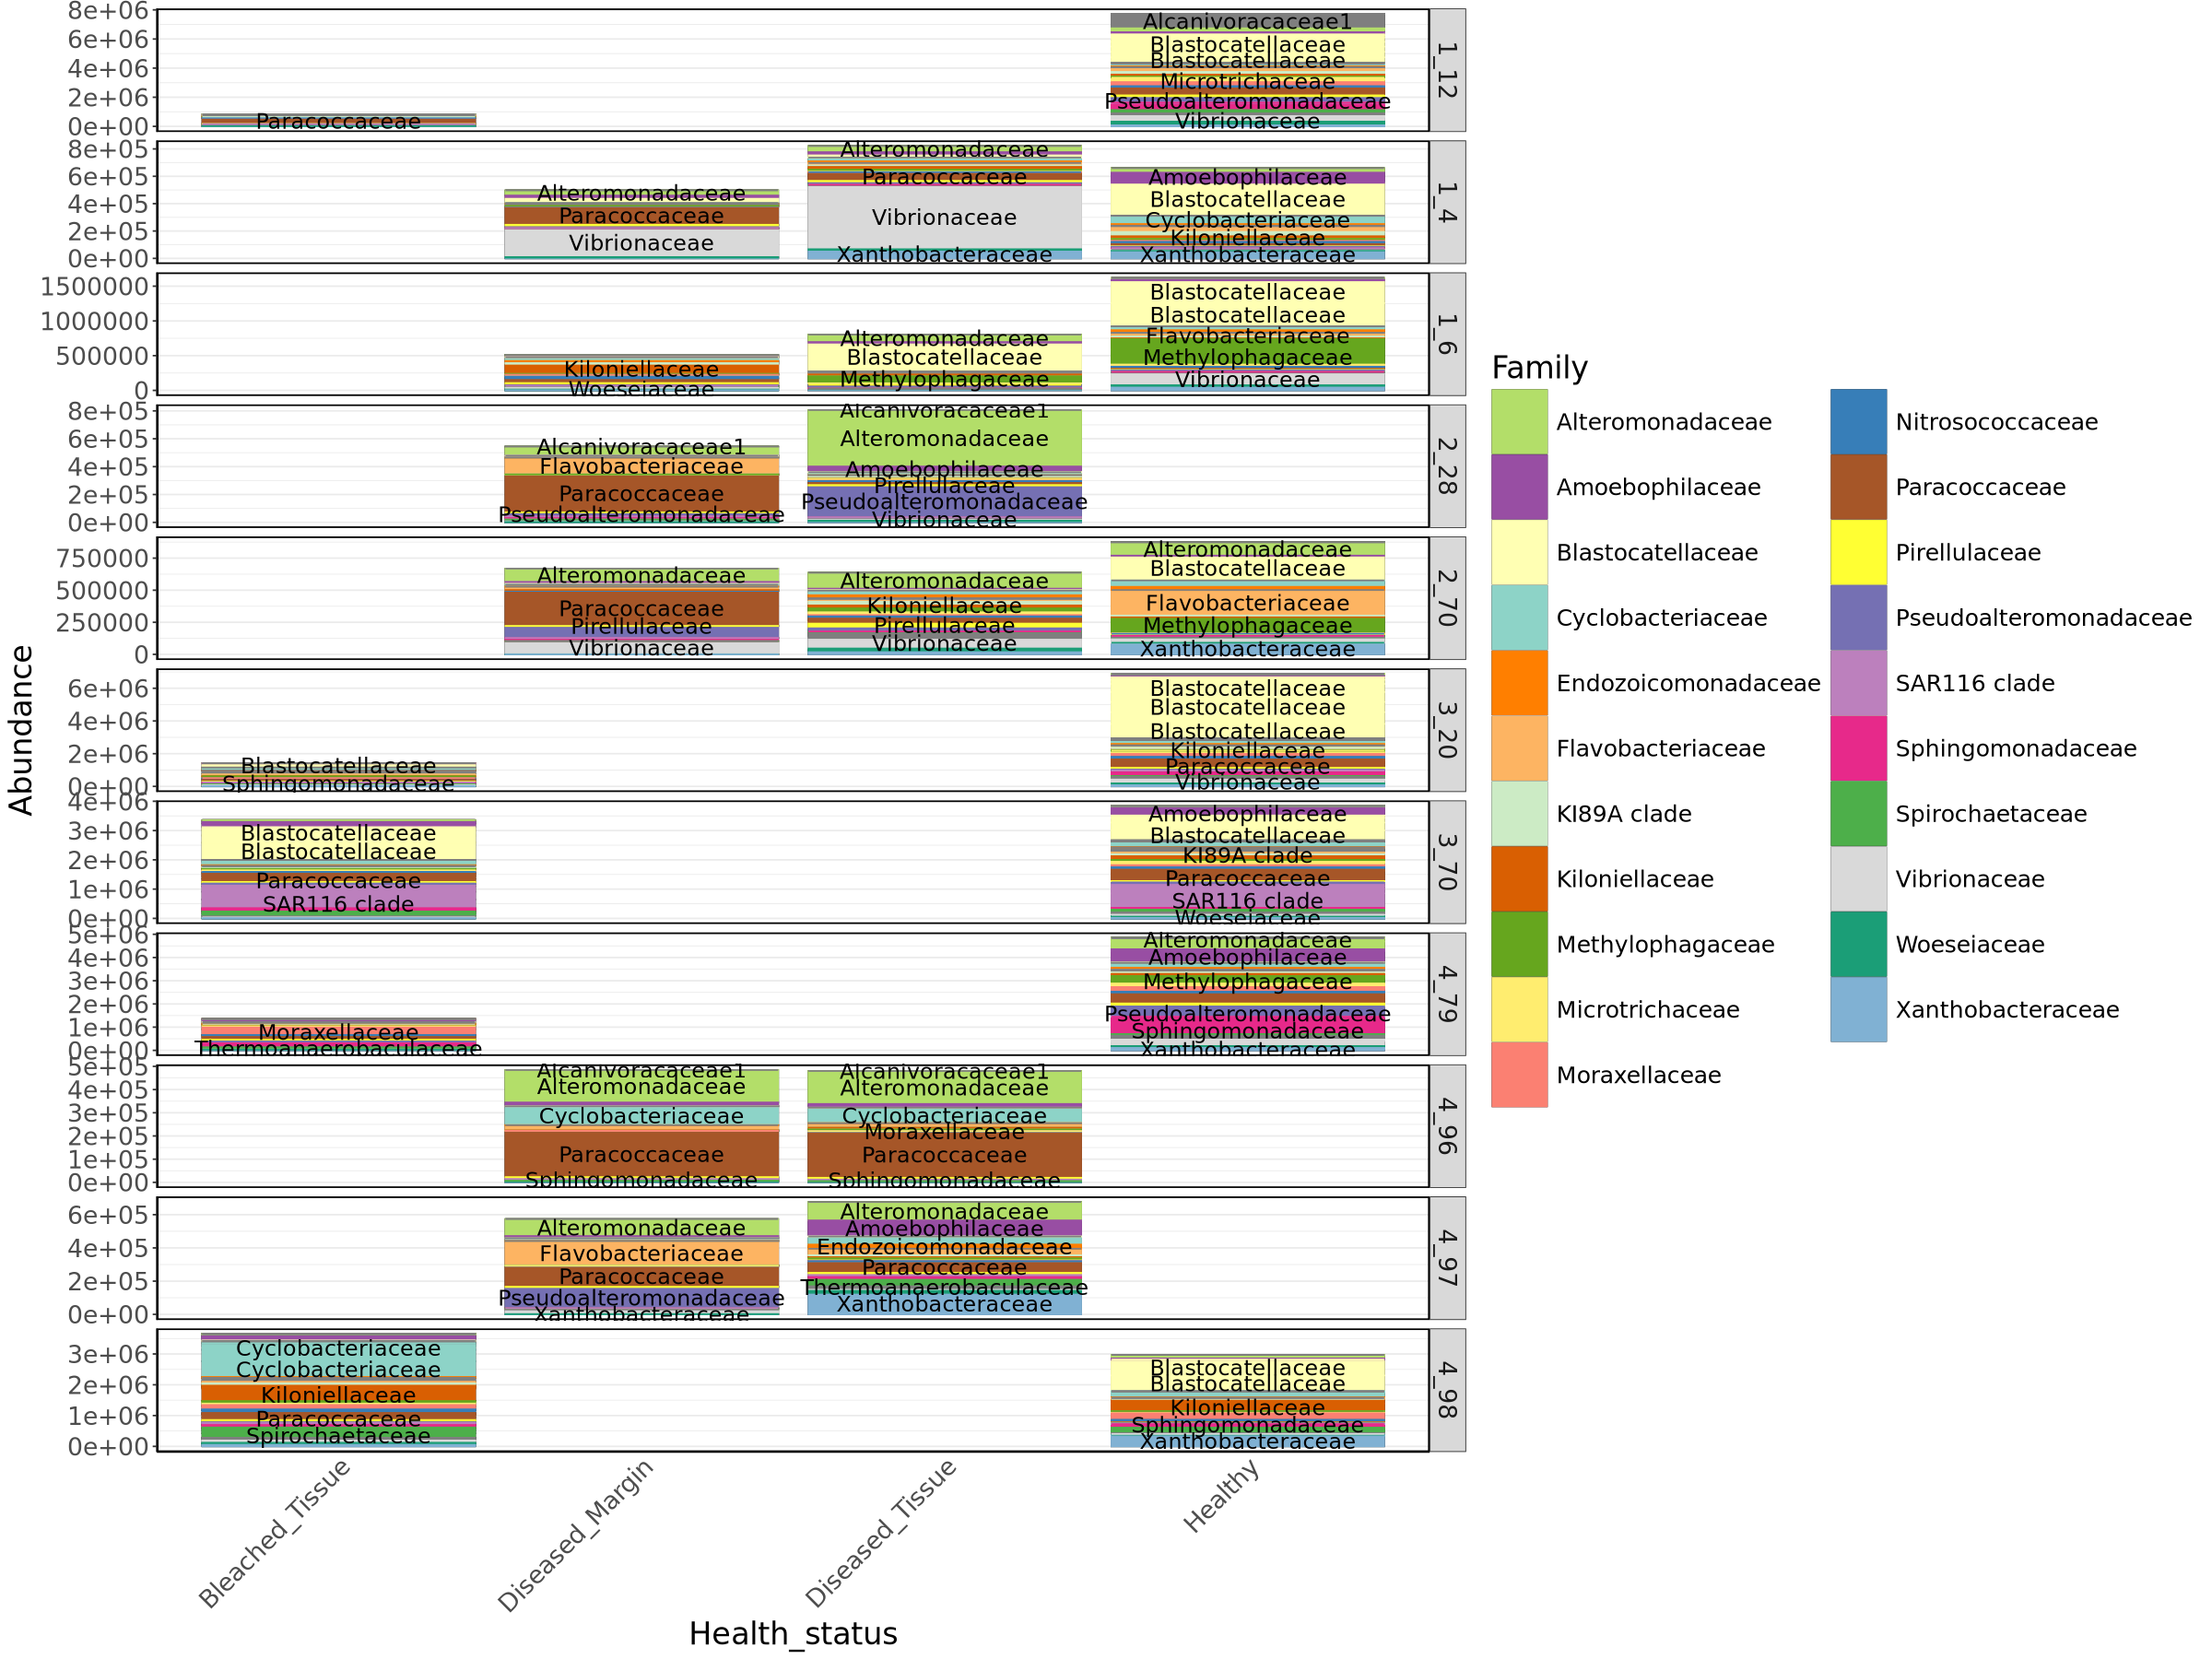

In [217]:
#plot
health_pstr <- plot_bar(fam25_pstr, x="Health_status", fill="Family") +
   facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 5, check_overlap = TRUE) +
  scale_fill_manual(values = my_colors, drop = TRUE) +
  scale_color_manual(values = my_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
health_pstr